[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


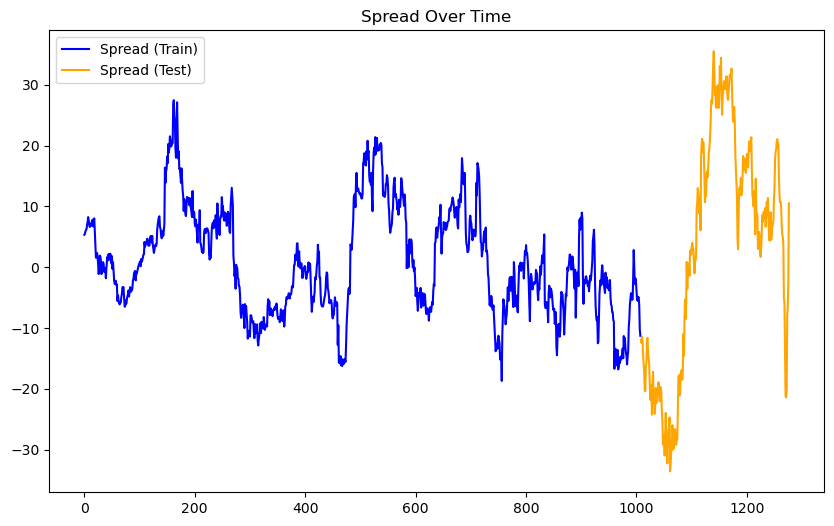

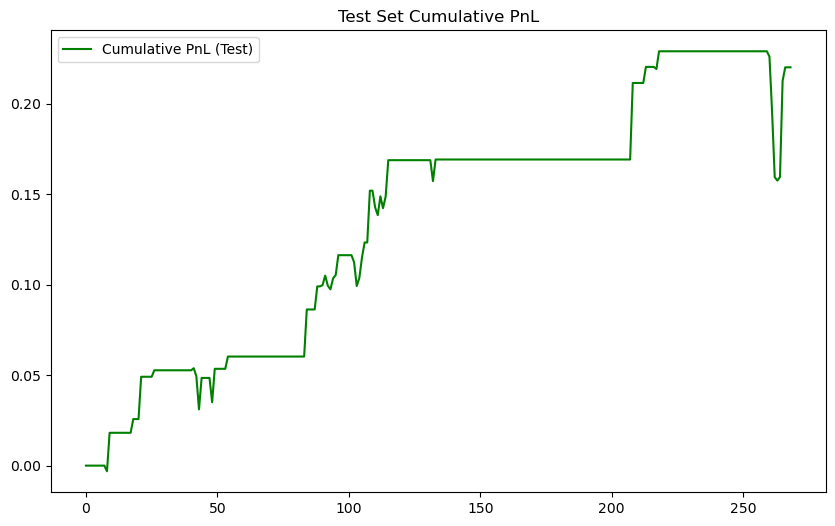

Test Set Sharpe Ratio: 1.91


In [64]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

###############################################################################
# Helper functions
###############################################################################
def lag1(x):
    """ Shift each column down by 1 row, placing NaN in the first row. """
    x_lag = np.roll(x, 1, axis=0)
    x_lag[0, :] = np.nan
    return x_lag

def fill_missing_data(positions):
    """ Forward-fill NaNs so that existing positions are carried forward. """
    df = pd.DataFrame(positions)
    df = df.ffill()
    return df.values

def annualized_sharpe(returns, sampling=252):
    """ Compute the annualized Sharpe ratio. """
    mu = np.nanmean(returns)
    sigma = np.nanstd(returns)
    return (np.sqrt(sampling) * mu) / sigma if sigma != 0 else np.nan

def max_drawdown(pnl):
    """ Compute maximum drawdown and duration. """
    cumulative_pnl = np.cumsum(pnl)
    peak = np.maximum.accumulate(cumulative_pnl)
    drawdown = cumulative_pnl - peak
    max_dd = np.min(drawdown)
    
    if max_dd < 0:
        drawdown_start = np.where(cumulative_pnl == peak[np.where(drawdown == max_dd)[0][0]])[0][0]
        drawdown_end = np.where(drawdown == max_dd)[0][-1]
        drawdown_duration = drawdown_end - drawdown_start if drawdown_end > drawdown_start else 1  # Ensure at least 1 day
    else:
        drawdown_duration = 0
    
    return max_dd, drawdown_duration

def information_ratio(pnl, benchmark_pnl):
    """ Compute the information ratio (excess return over benchmark). """
    excess_return = pnl - benchmark_pnl
    return np.nanmean(excess_return) / np.nanstd(excess_return) if np.nanstd(excess_return) != 0 else np.nan

def plot_results(spread, pnl_test, trainset, testset):
    """ Plots spread and cumulative PnL charts. """
    plt.figure(figsize=(10,6))
    plt.plot(trainset, spread[trainset], label='Spread (Train)', color='blue')
    plt.plot(testset, spread[testset], label='Spread (Test)', color='orange')
    plt.title("Spread Over Time")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(10,6))
    plt.plot(np.nancumsum(pnl_test), label='Cumulative PnL (Test)', color='green')
    plt.title("Test Set Cumulative PnL")
    plt.legend()
    plt.show()

###############################################################################
# Data Fetching and Processing
###############################################################################
def run_strategy(long_threshold, short_threshold, exit_threshold, hedge_ratio_lookback, lookback_window):
    """
    Runs the pairs trading strategy with given parameters and returns the test set Sharpe ratio.
    """
    # Fetch Data
    start_date = "2020-01-01"
    end_date   = "2025-01-31"
    pair_1 = "AAPL"
    pair_2 = "MSFT"

    df1 = yf.download(pair_1, start=start_date, end=end_date)[['Adj Close']]
    df2 = yf.download(pair_2, start=start_date, end=end_date)[['Adj Close']]

    df1 = df1.rename(columns={'Adj Close': pair_1})
    df2 = df2.rename(columns={'Adj Close': pair_2})

    data = pd.merge(df1, df2, left_index=True, right_index=True, how='inner')
    data.dropna(inplace=True)

    tday = data.index.strftime('%Y%m%d').astype(int)
    cl1 = data[pair_1].values
    cl2 = data[pair_2].values

    # Define Train and Test Set
    train_len = 1008
    testset = np.arange(train_len, len(tday))
    trainset = np.arange(0, train_len)

    # Hedge Ratio Calculation (Rolling Window)
    hedge_ratios = np.full(len(tday), np.nan)
    for i in range(hedge_ratio_lookback, len(tday)):
        X_train = cl2[i-hedge_ratio_lookback:i].reshape(-1, 1)
        y_train = cl1[i-hedge_ratio_lookback:i]
        model = sm.OLS(y_train, X_train, hasconst=False)
        results = model.fit()
        hedge_ratios[i] = results.params[0]
    hedge_ratios[:hedge_ratio_lookback] = hedge_ratios[hedge_ratio_lookback]  # Fill initial values

    # Compute Spread and Z-score
    spread = cl1 - hedge_ratios * cl2
    spread_mean = pd.Series(spread).rolling(window=lookback_window).mean()
    spread_std = pd.Series(spread).rolling(window=lookback_window).std()
    zscore = (spread - spread_mean) / spread_std
    
    # Generate Trading Signals
    longs = (zscore <= long_threshold)
    shorts = (zscore >= short_threshold)
    exits = (abs(zscore) <= exit_threshold)

    positions = np.zeros((len(tday), 2))
    positions[shorts, :] = [-1, 1]
    positions[longs, :] = [1, -1]
    positions[exits, :] = [0, 0]
    positions = pd.DataFrame(positions).fillna(method="ffill").fillna(0).values

    # Compute PnL
    cl = np.column_stack([cl1, cl2])
    cl_lag = lag1(cl)
    daily_ret = (cl - cl_lag) / cl_lag
    positions_lag = np.roll(positions, shift=1, axis=0)
    positions_lag[0, :] = 0
    
    pnl = np.nansum(positions_lag * daily_ret, axis=1)

    # Compute Sharpe Ratio for Test Set
    pnl_test = pnl[testset]
    sharpe_test = annualized_sharpe(pnl_test)
    
    plot_results(spread, pnl_test, trainset, testset)
    return sharpe_test  # Return only test set Sharpe Ratio

###############################################################################
# Run strategy and plot results
###############################################################################
sharpe = run_strategy(-2, 2, 0.5, 100, 100)
print(f"Test Set Sharpe Ratio: {sharpe:.2f}")

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


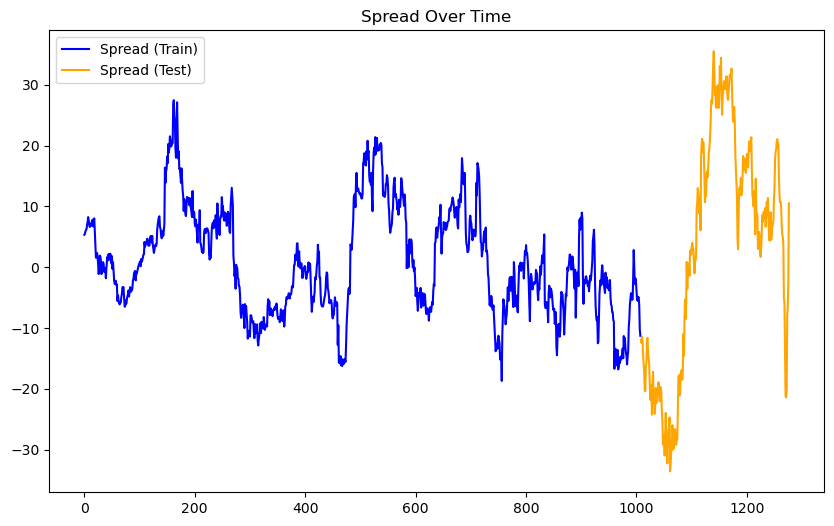

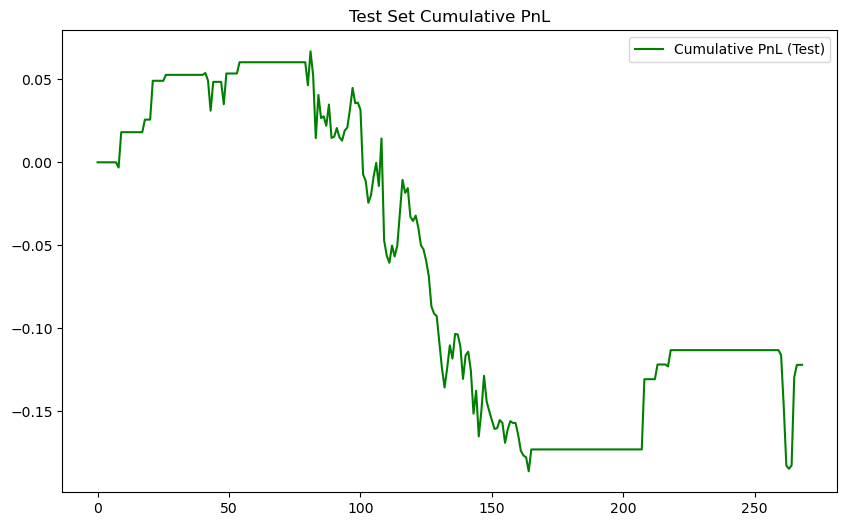

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


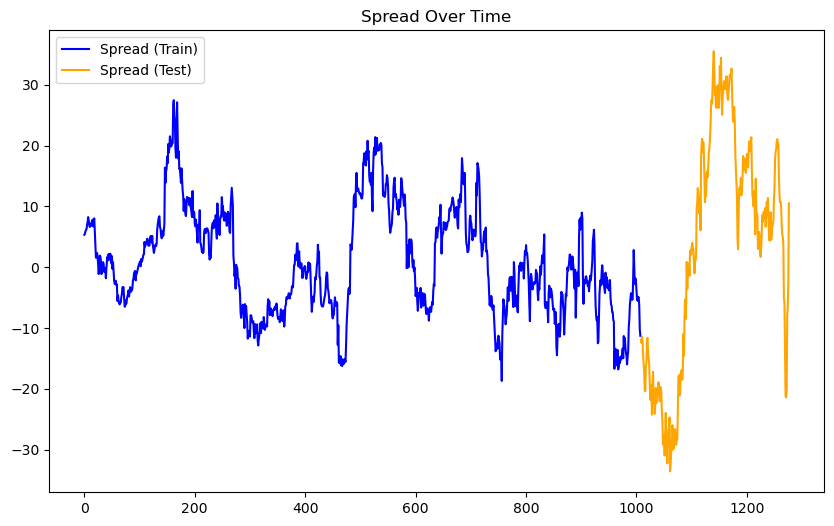

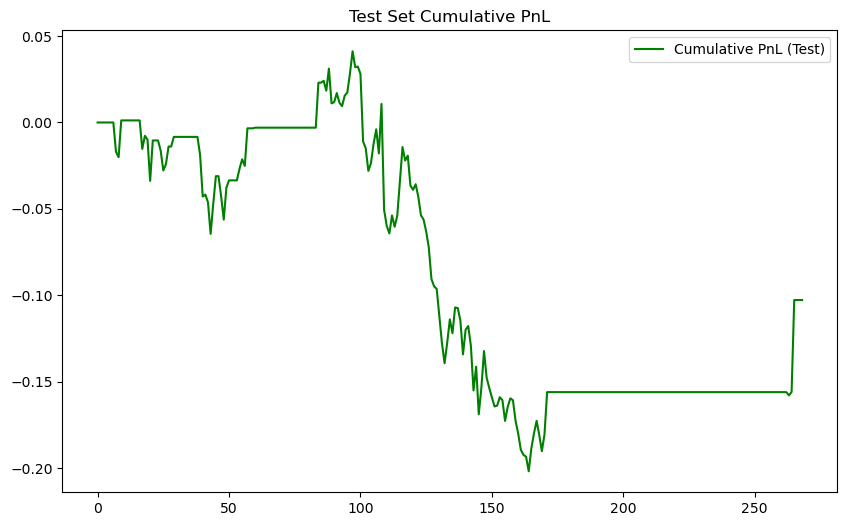

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


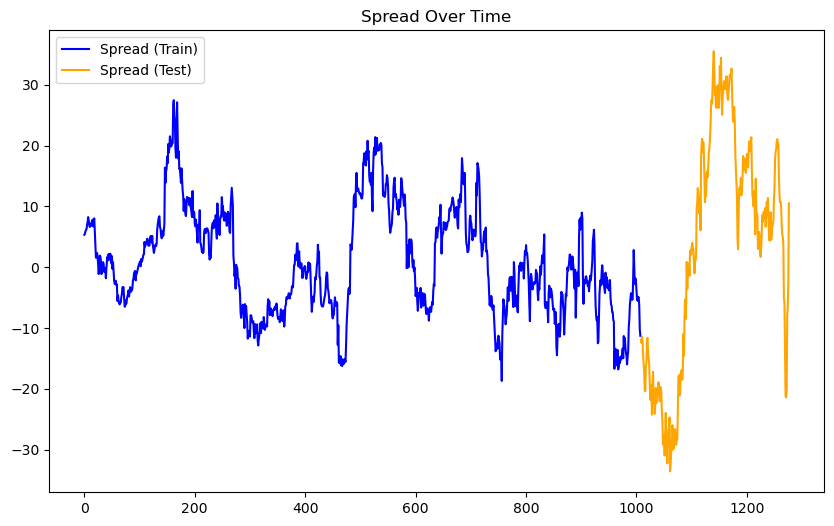

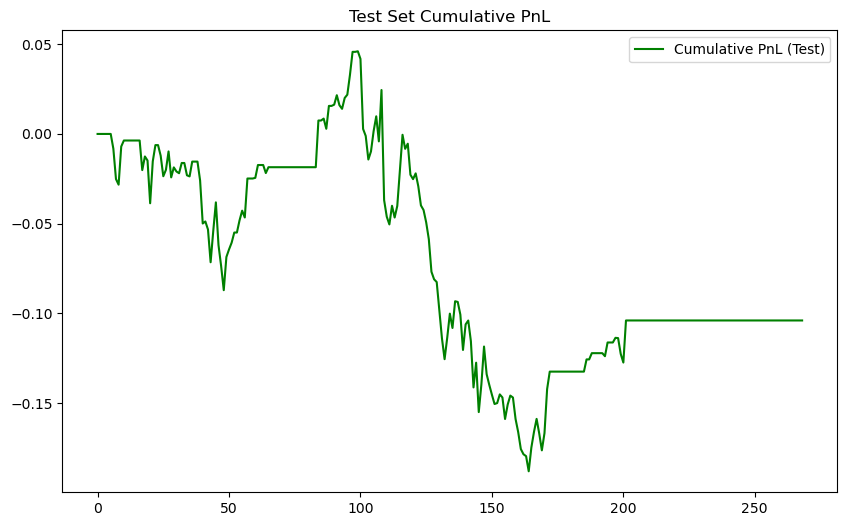

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


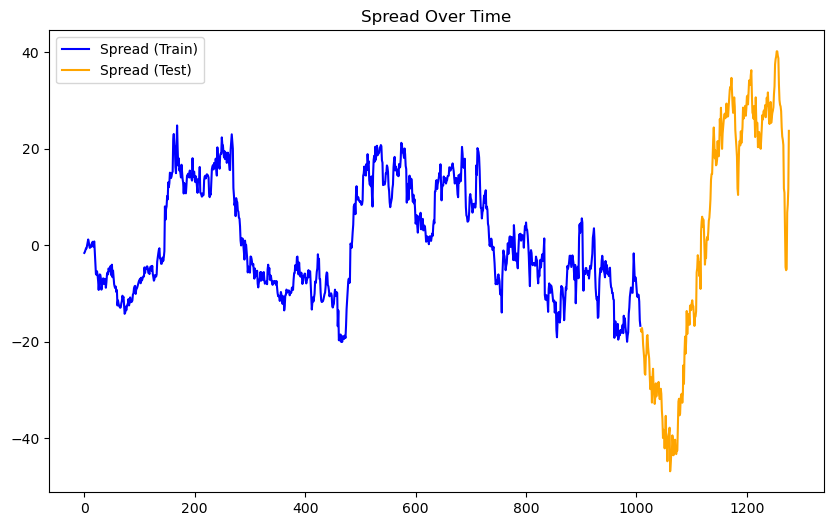

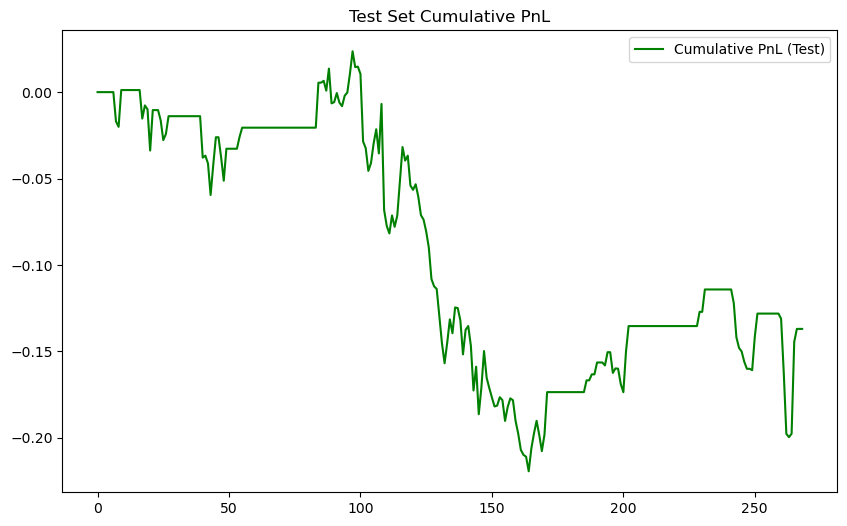

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


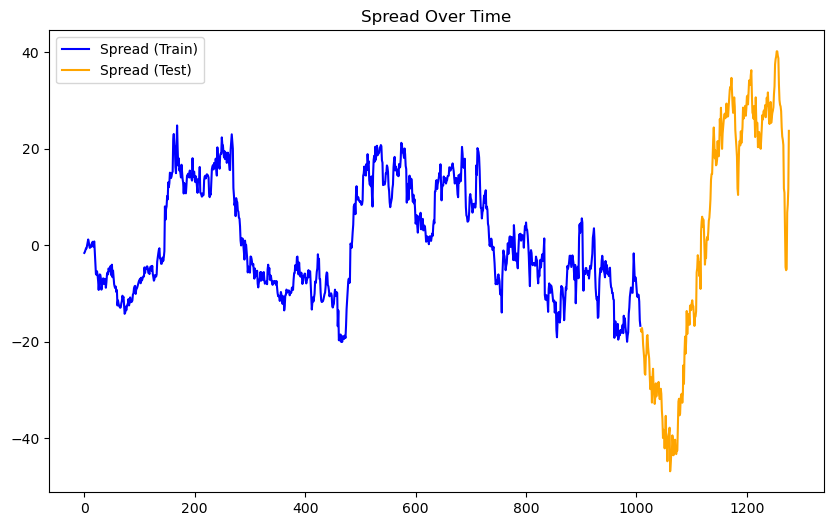

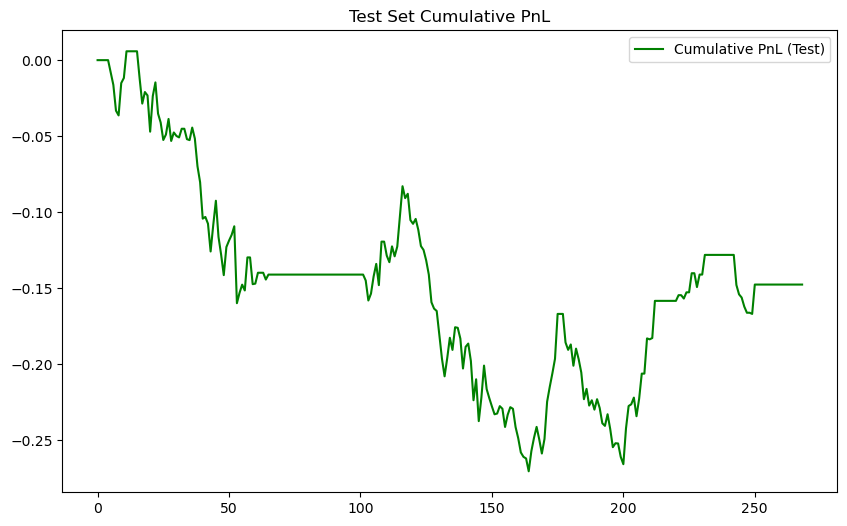

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


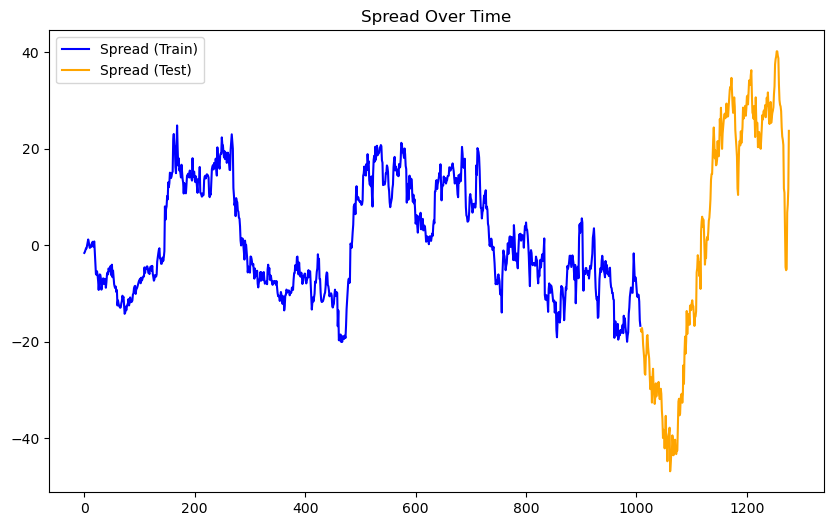

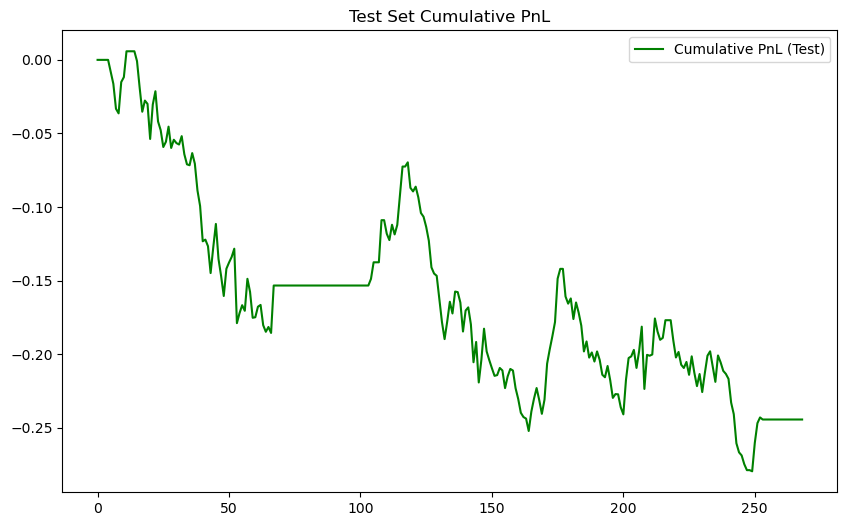

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


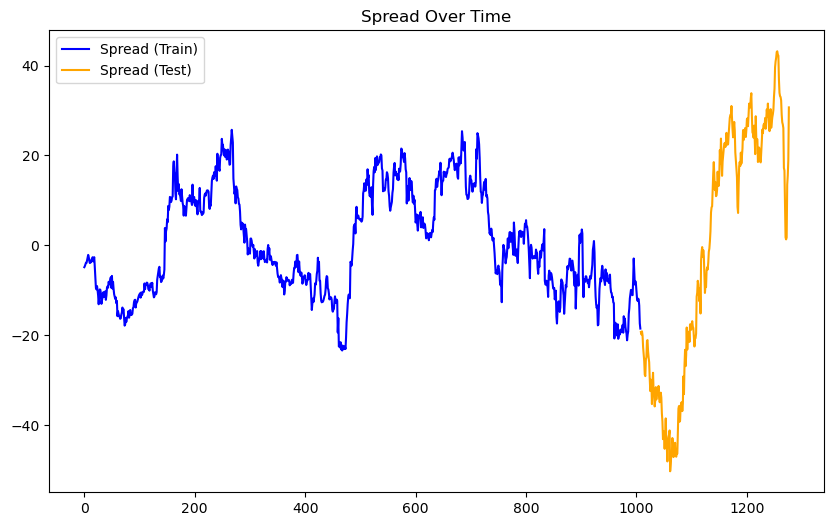

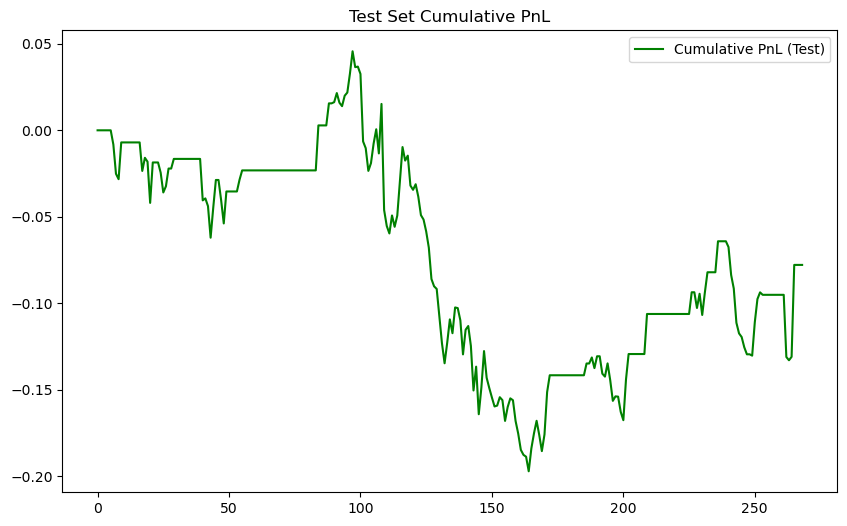

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


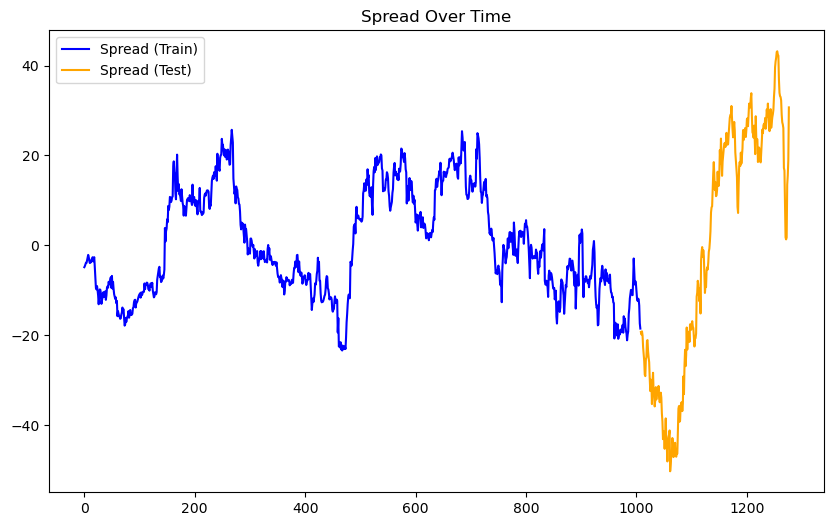

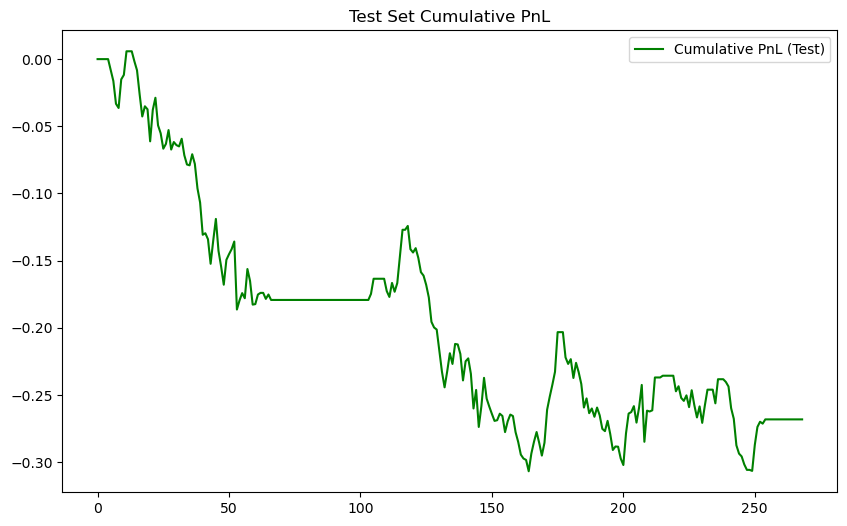

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


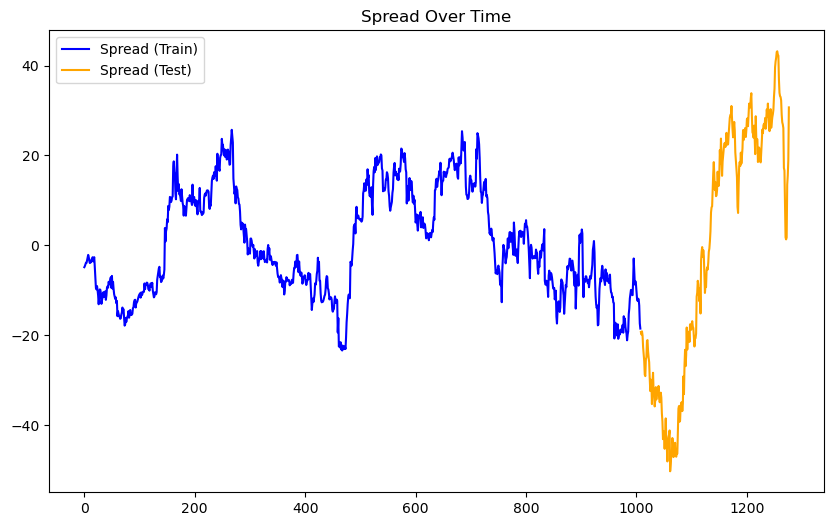

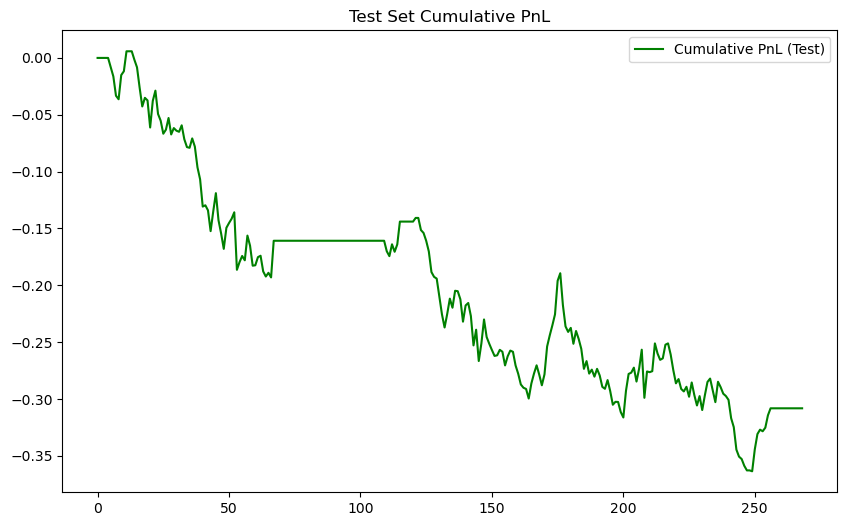

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


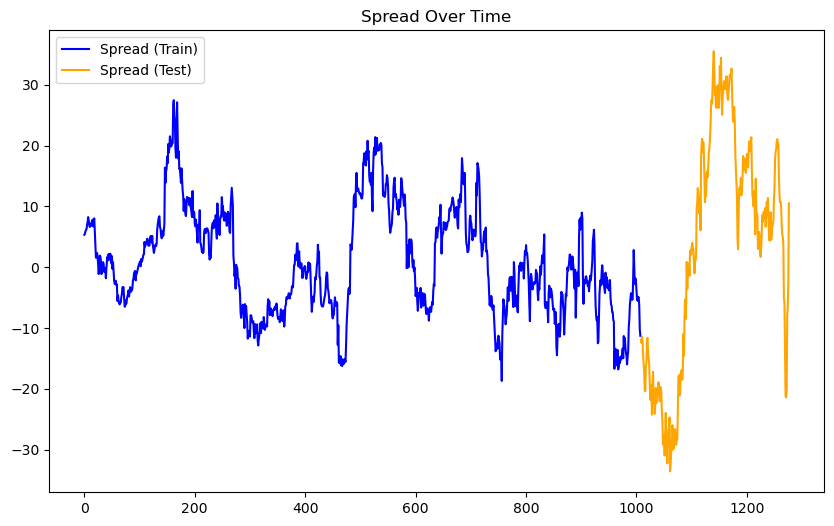

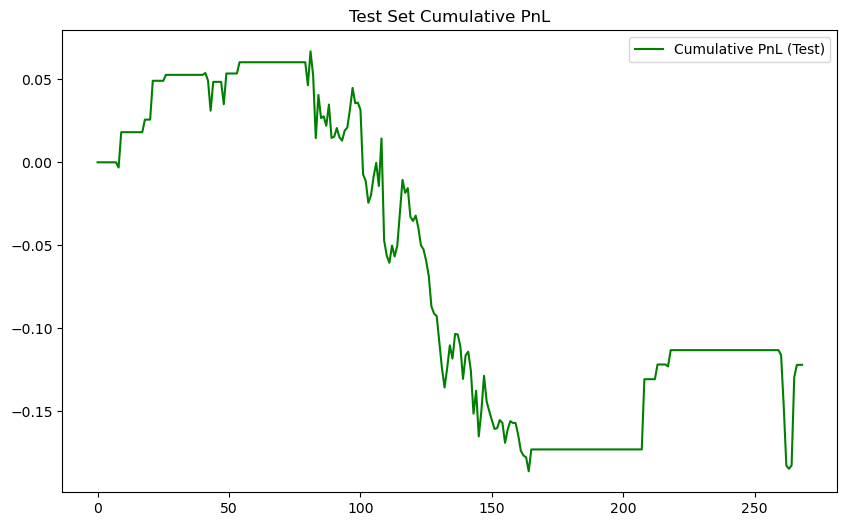

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


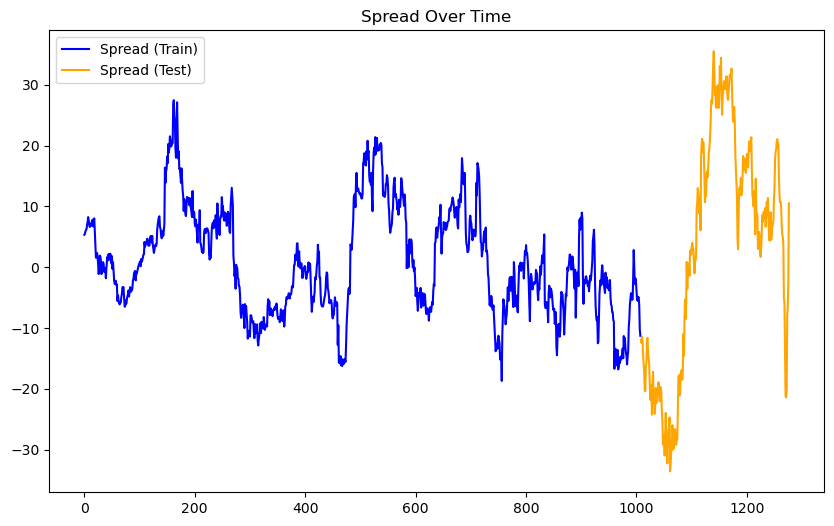

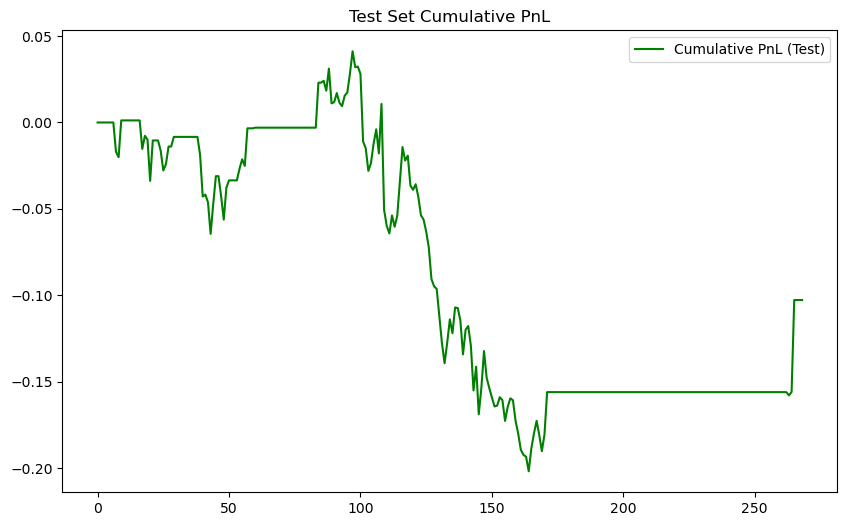

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


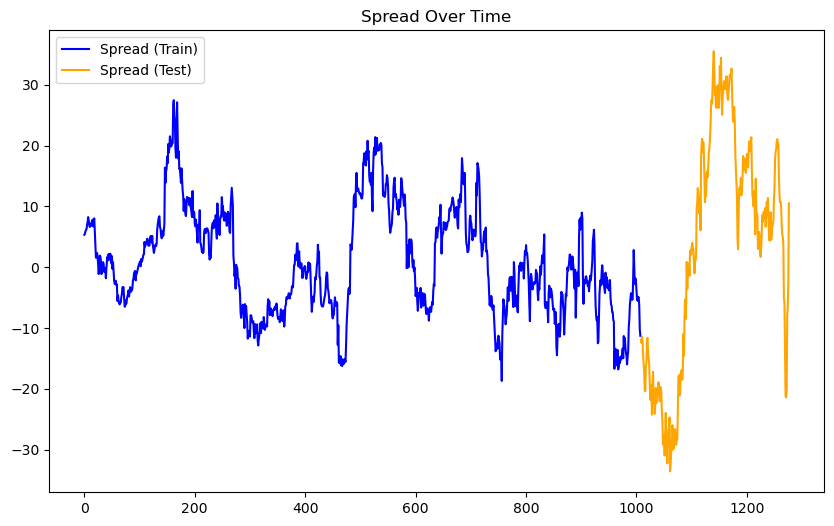

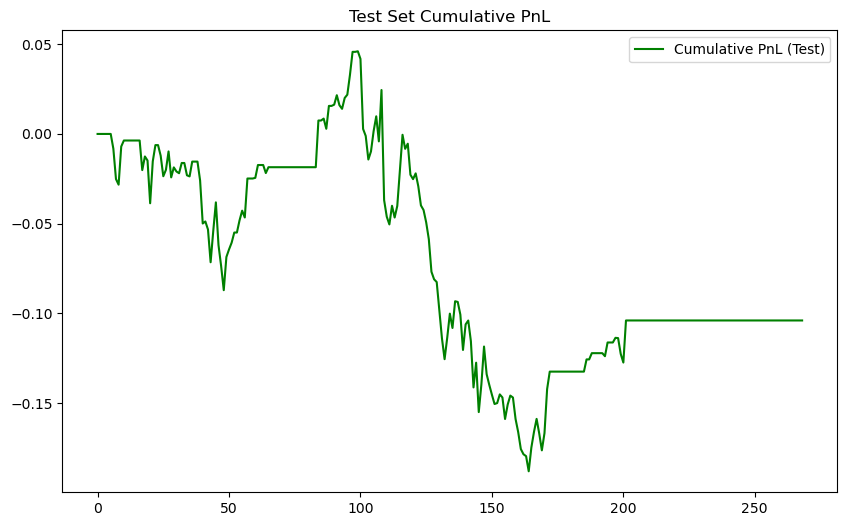

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


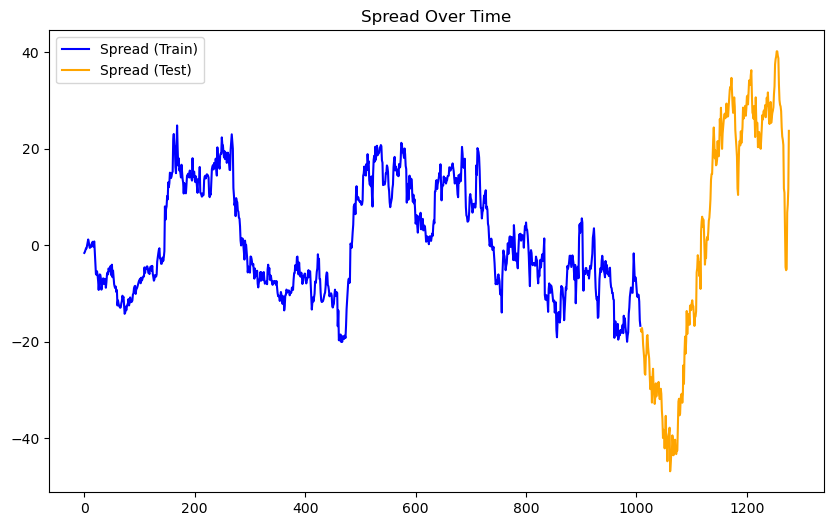

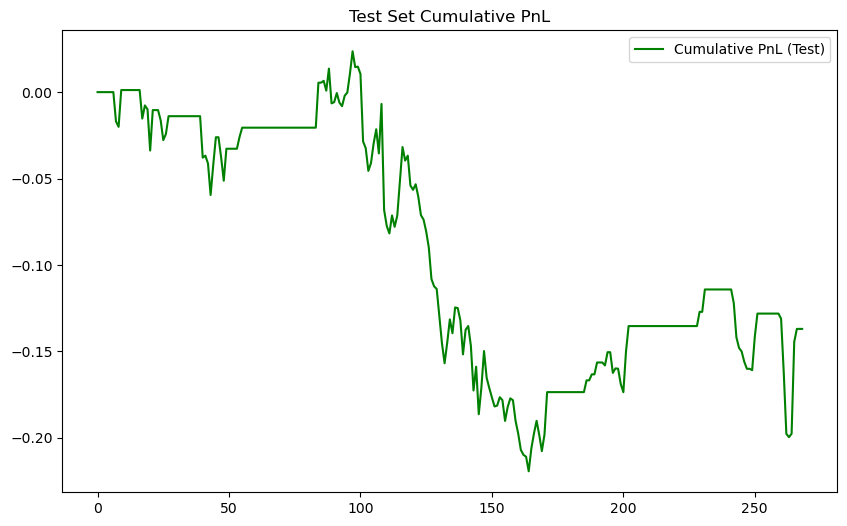

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


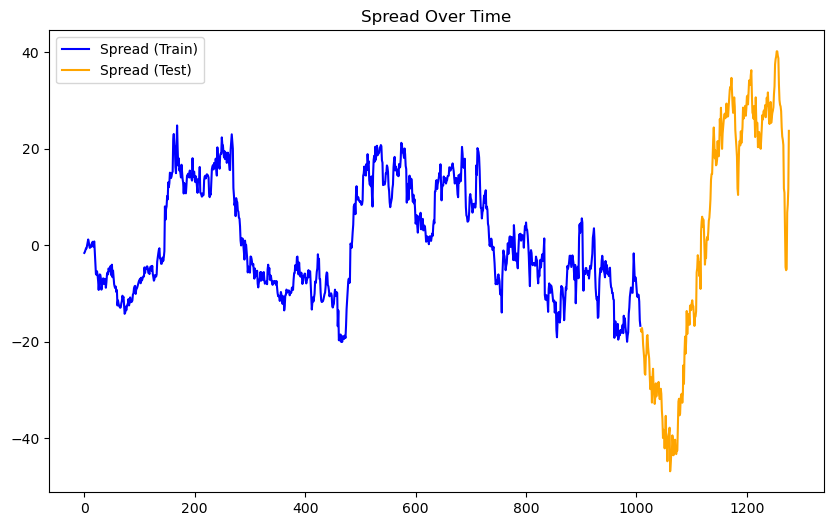

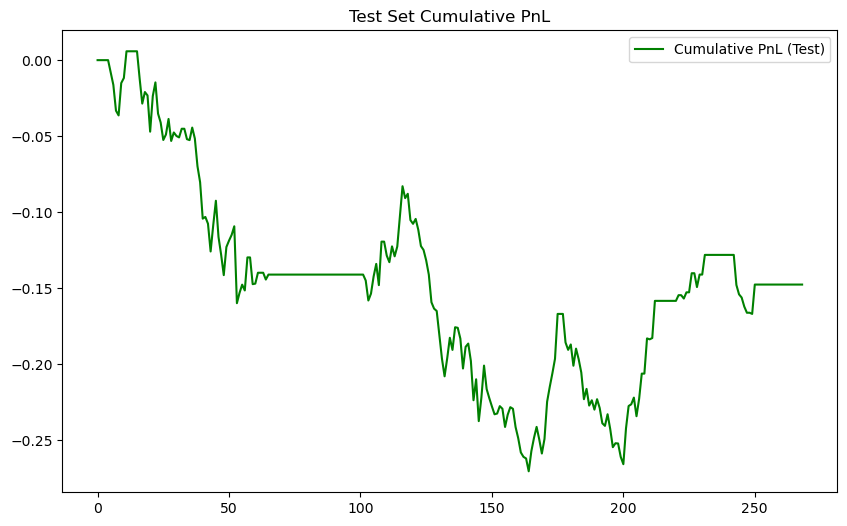

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


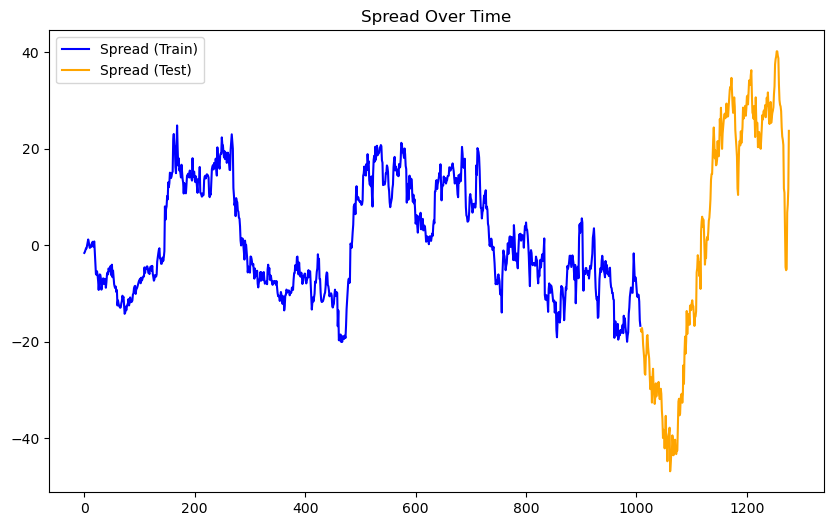

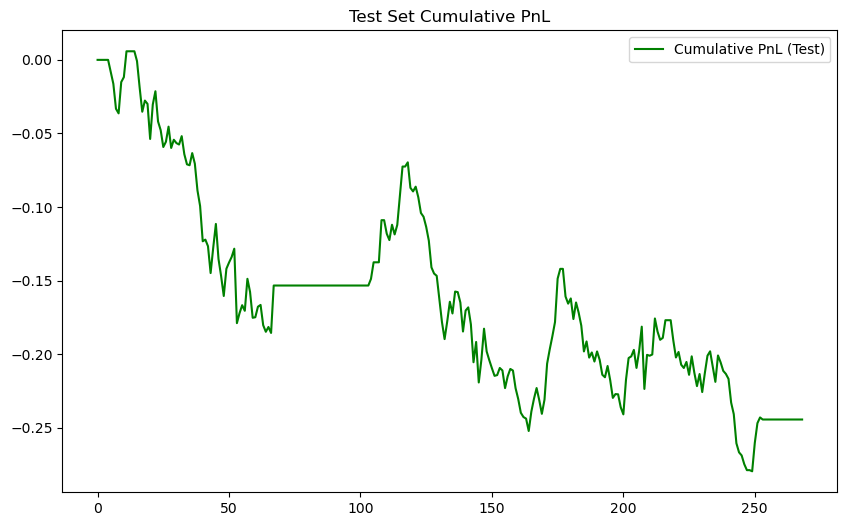

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


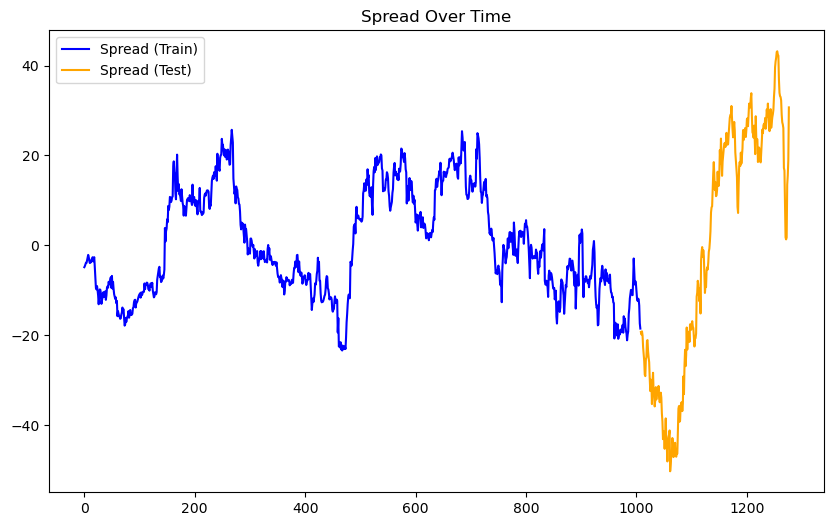

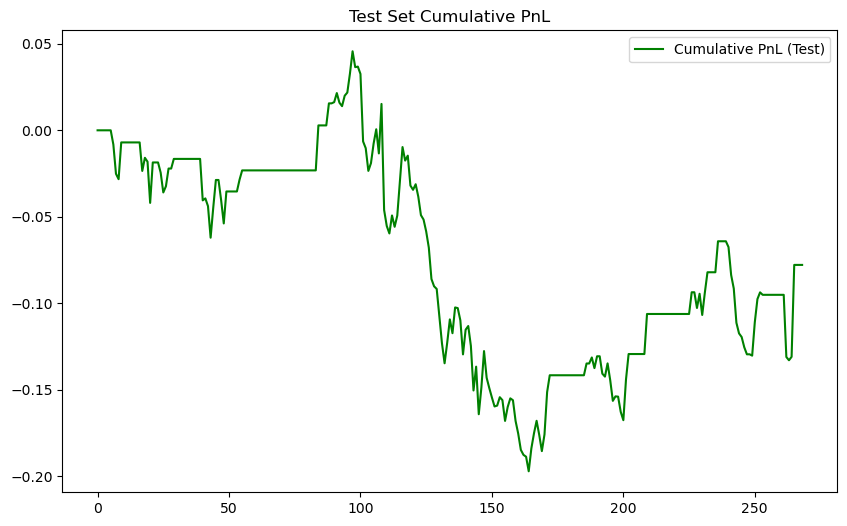

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


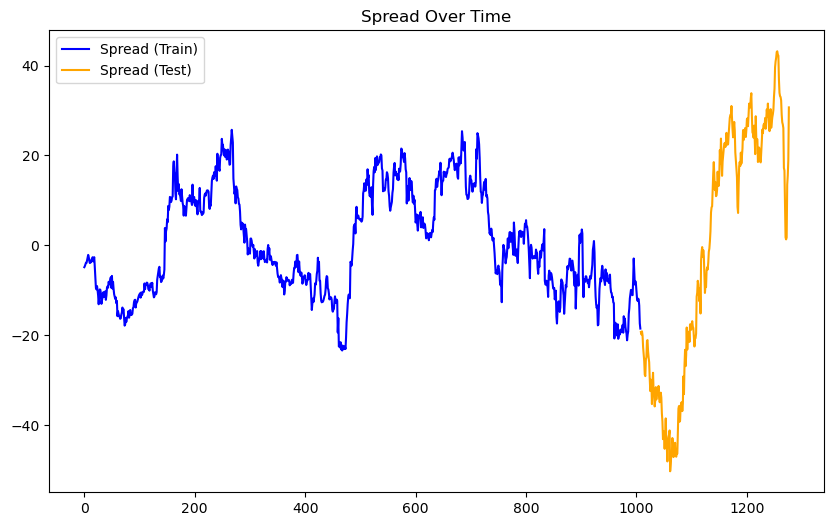

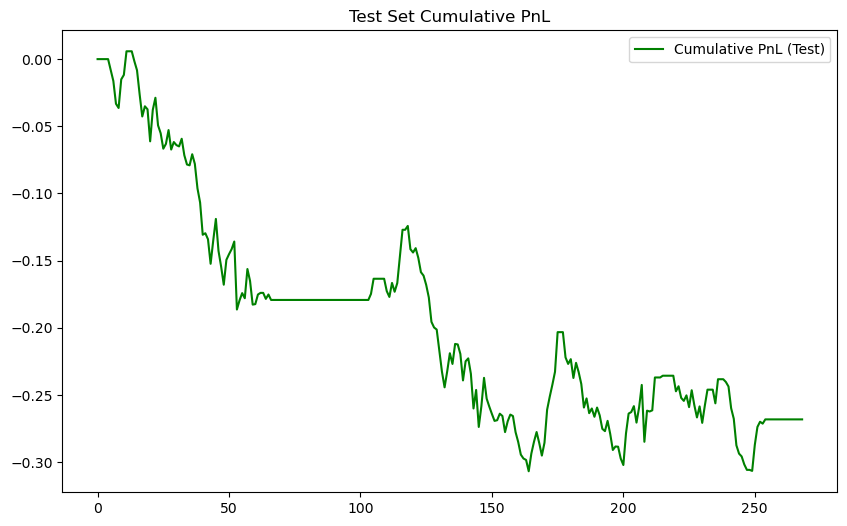

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


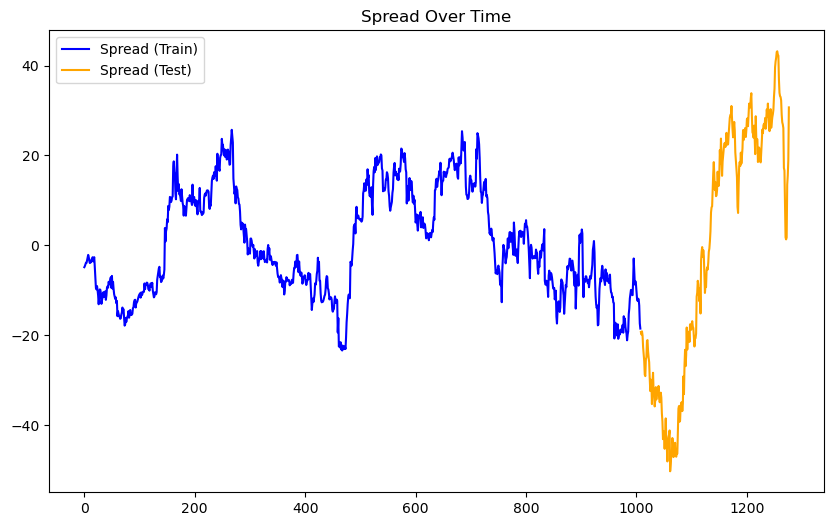

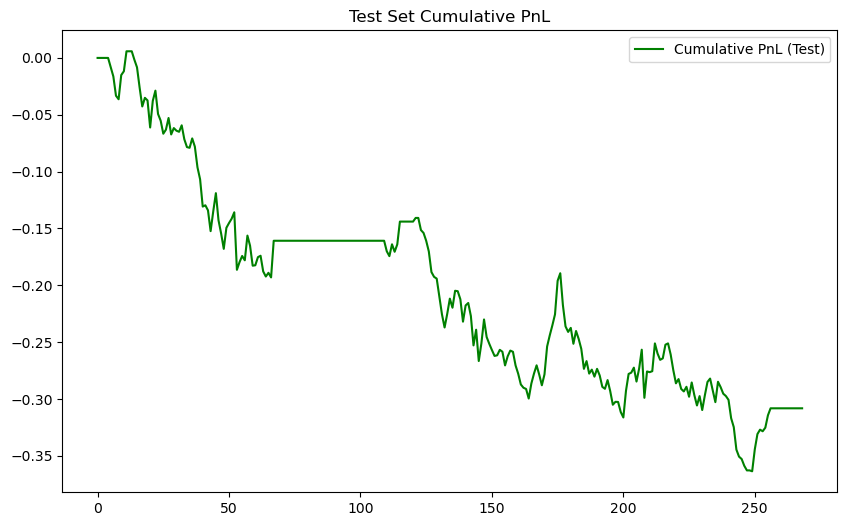

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


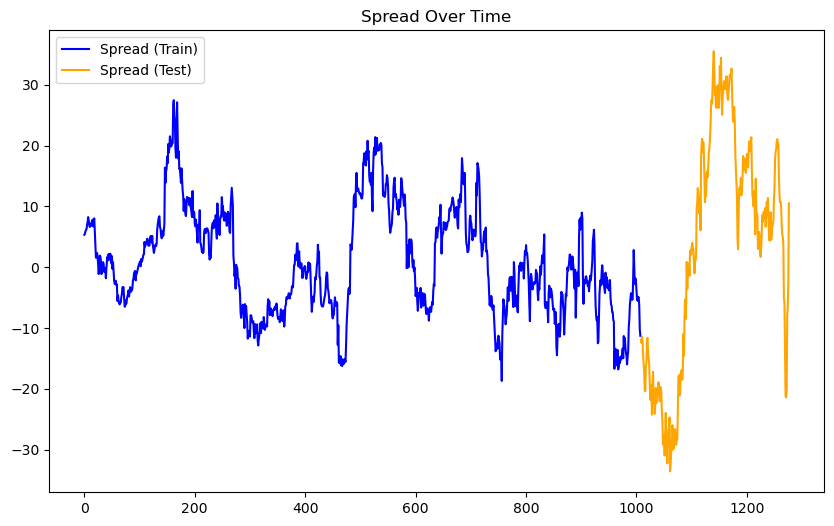

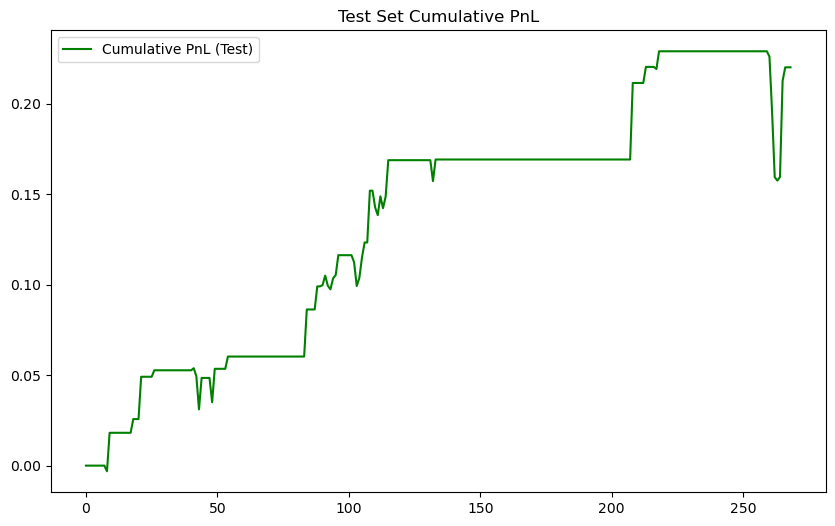

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


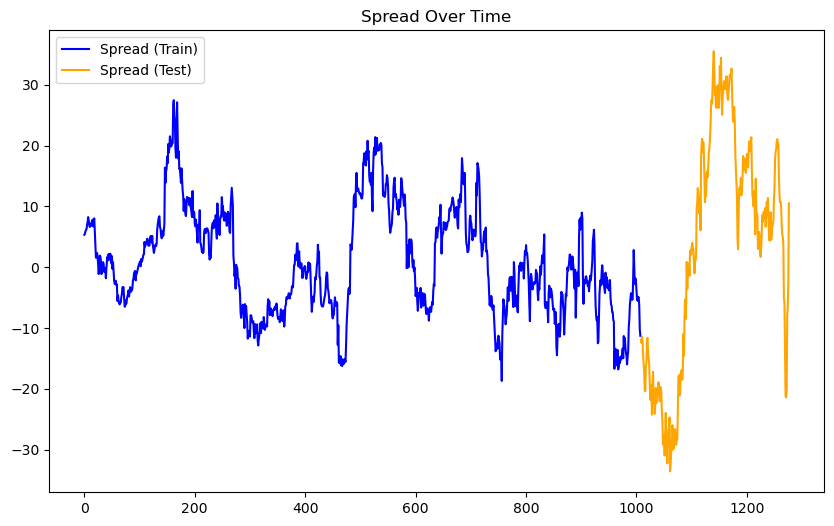

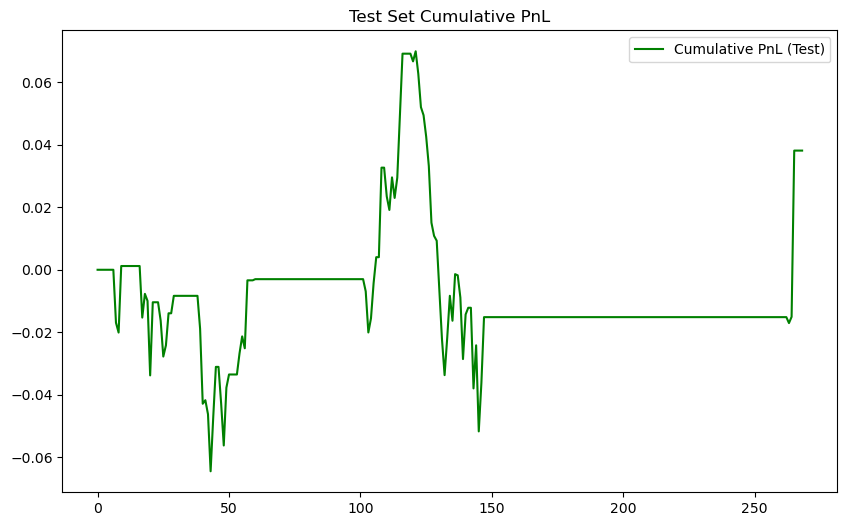

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


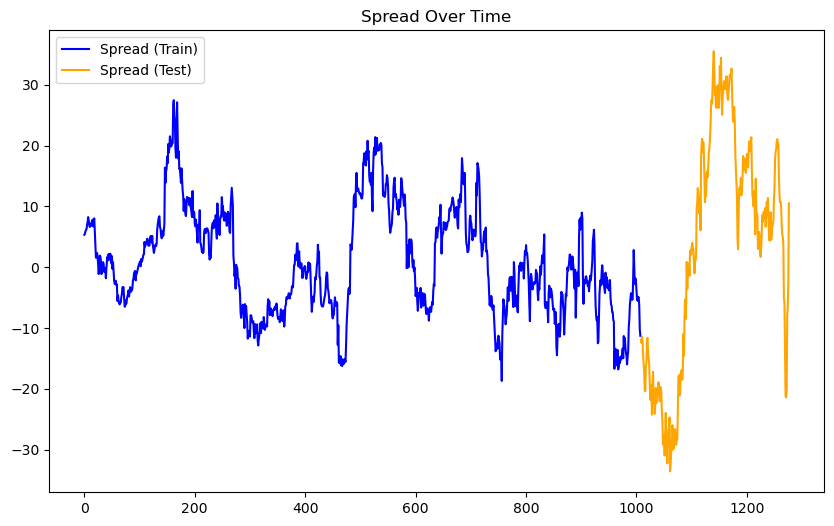

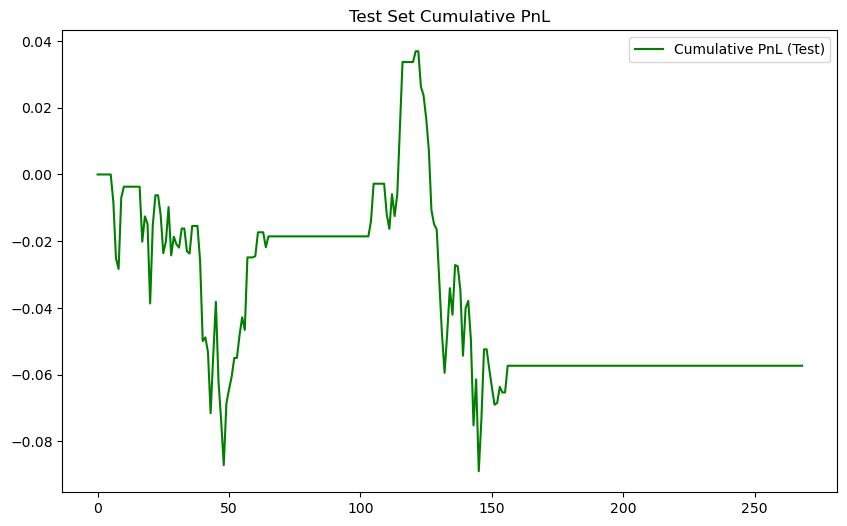

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


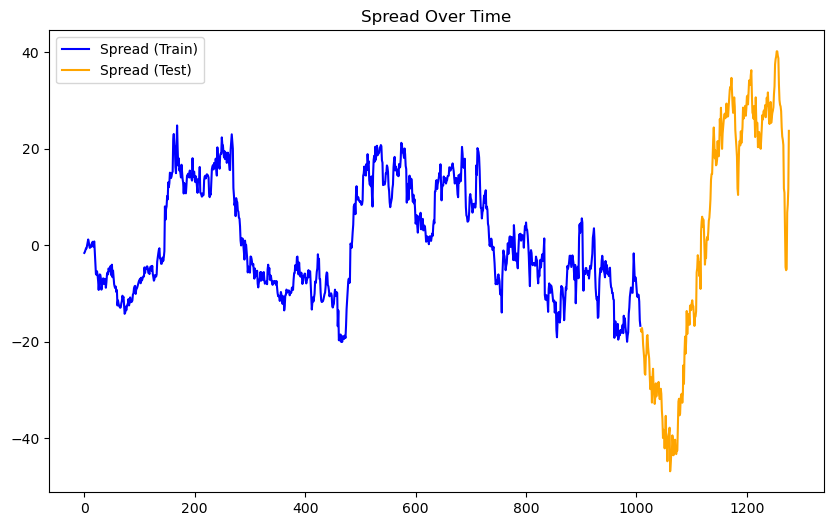

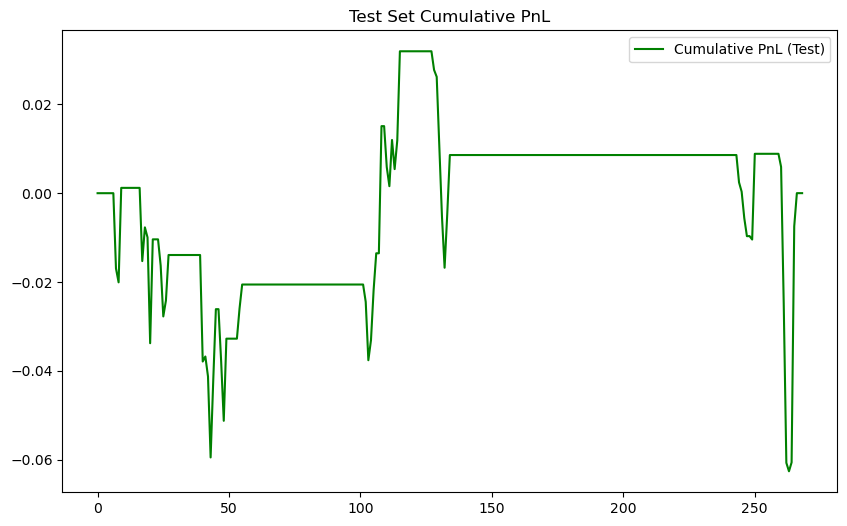

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


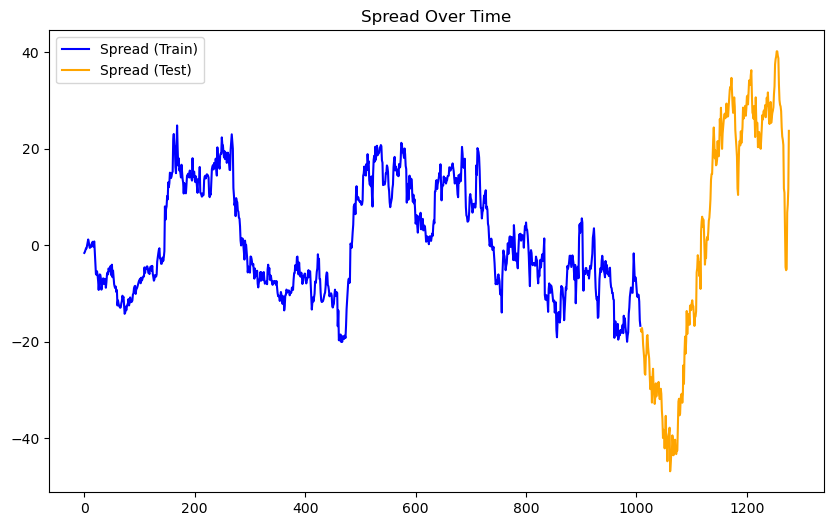

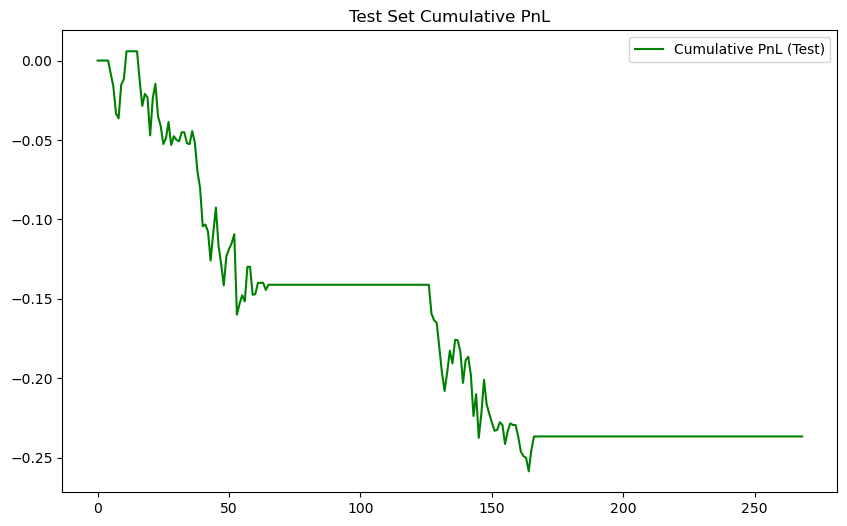

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


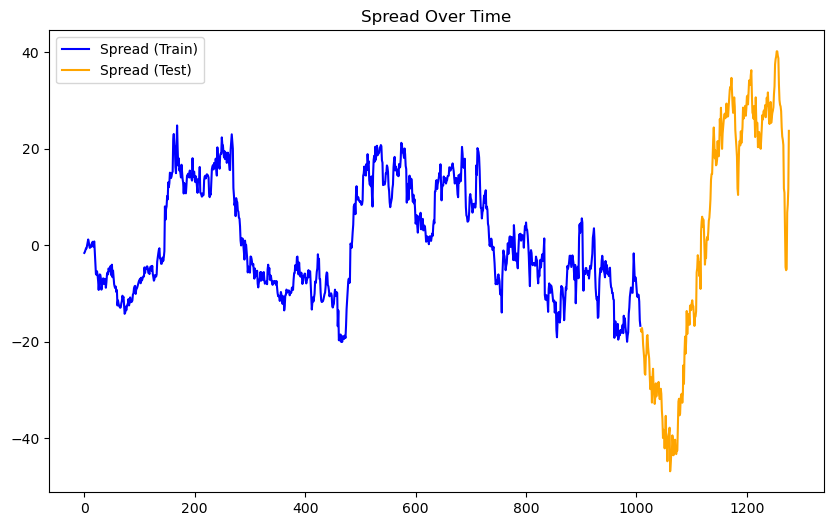

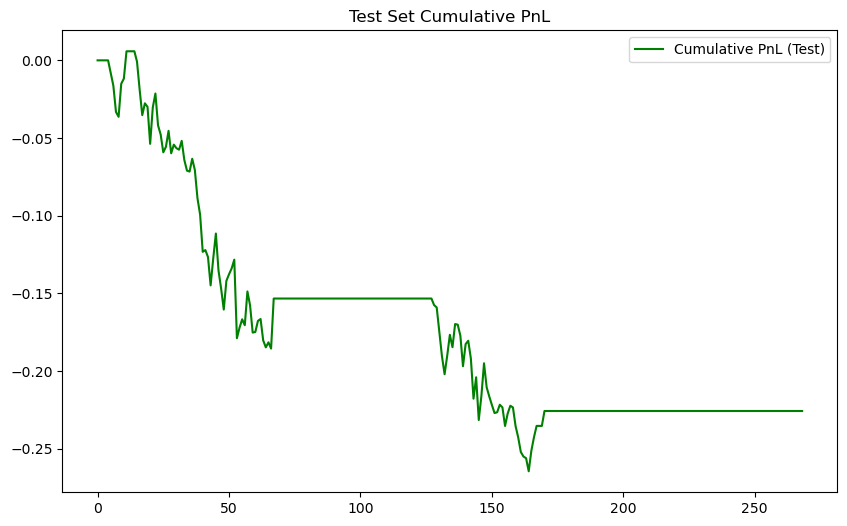

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


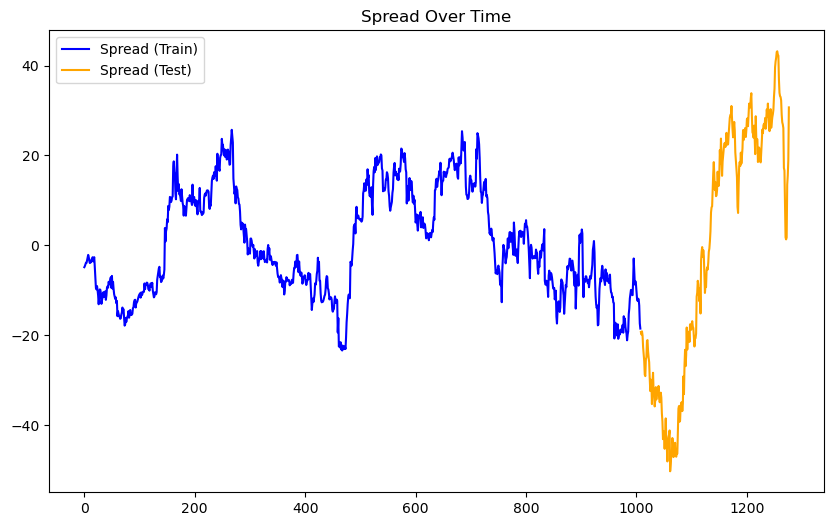

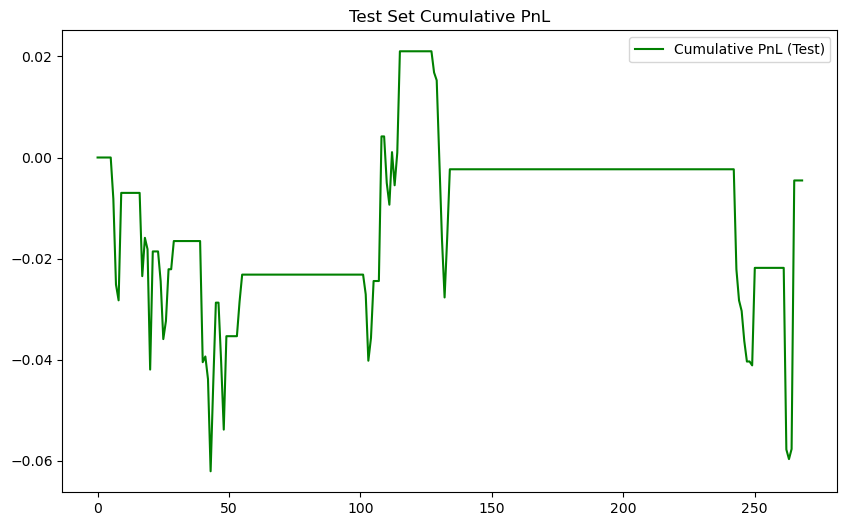

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


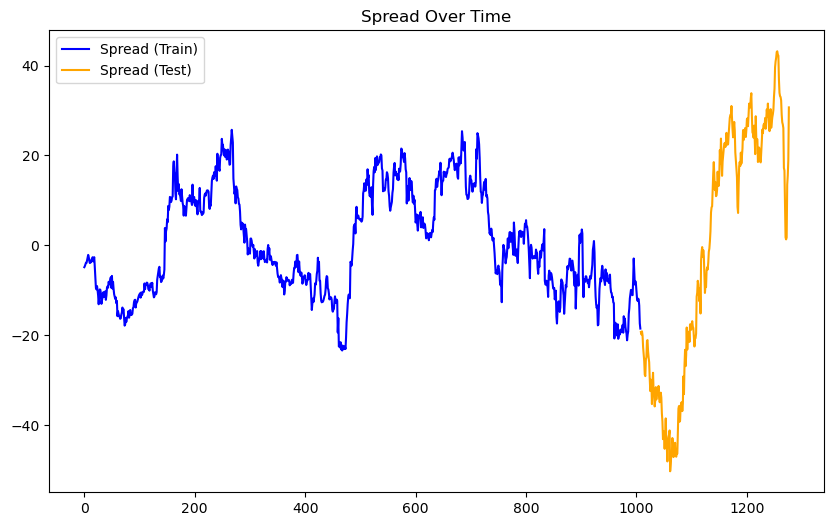

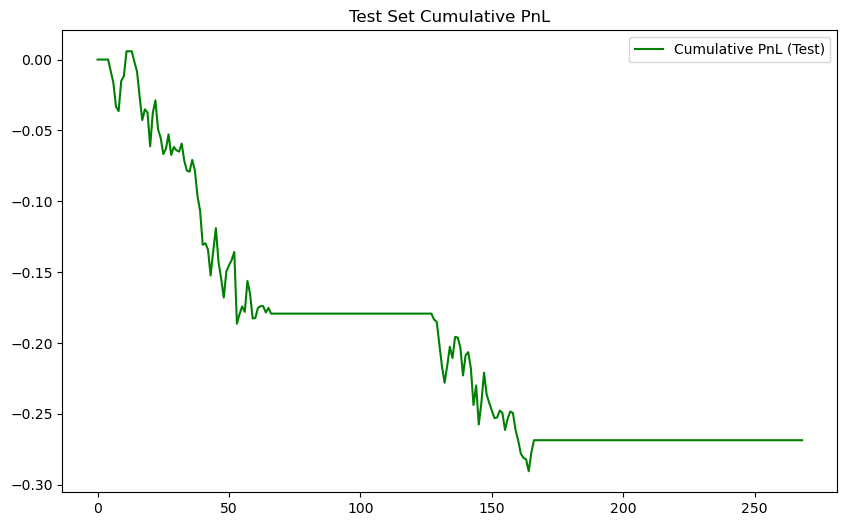

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


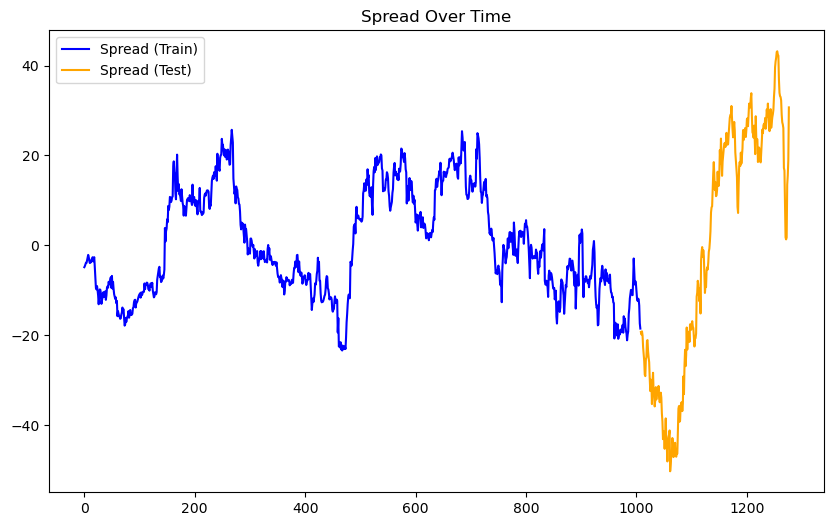

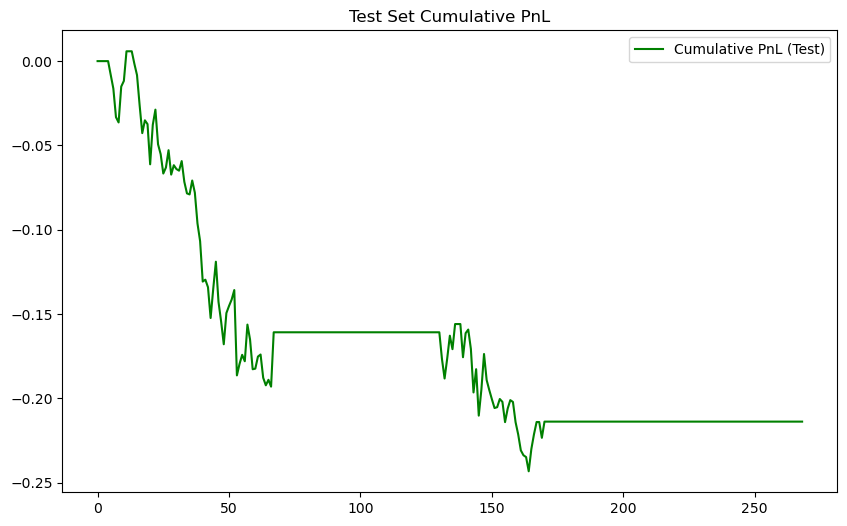

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


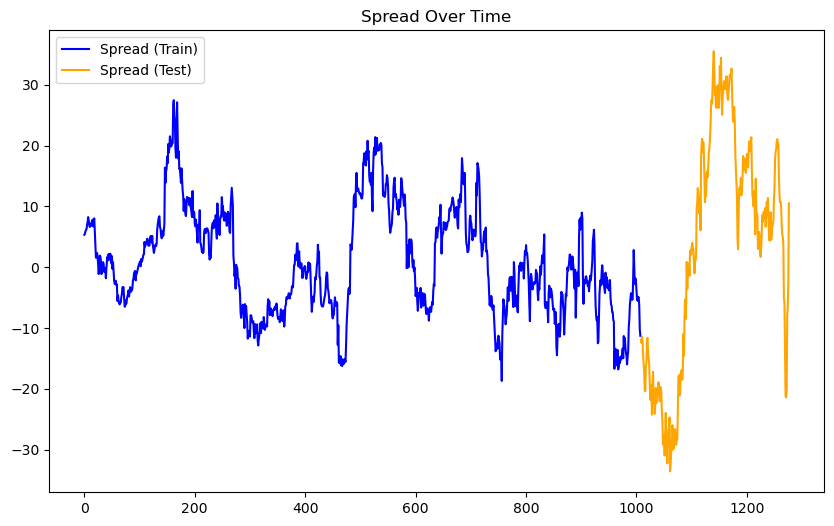

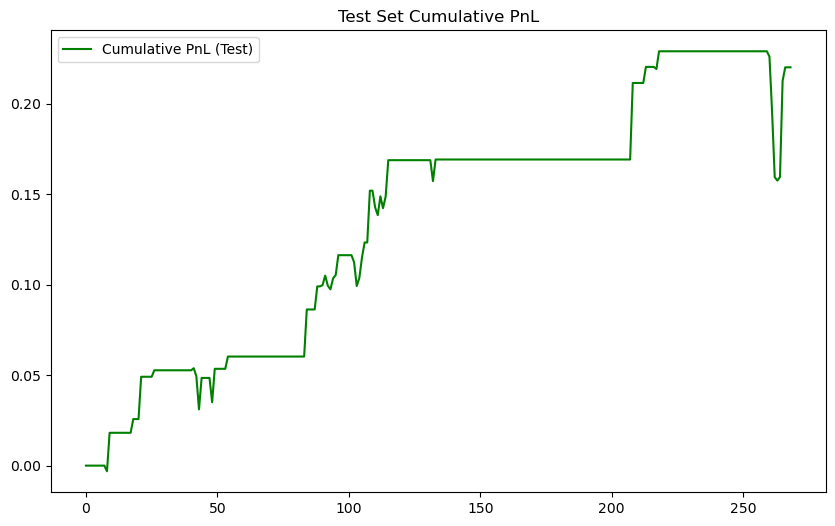

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


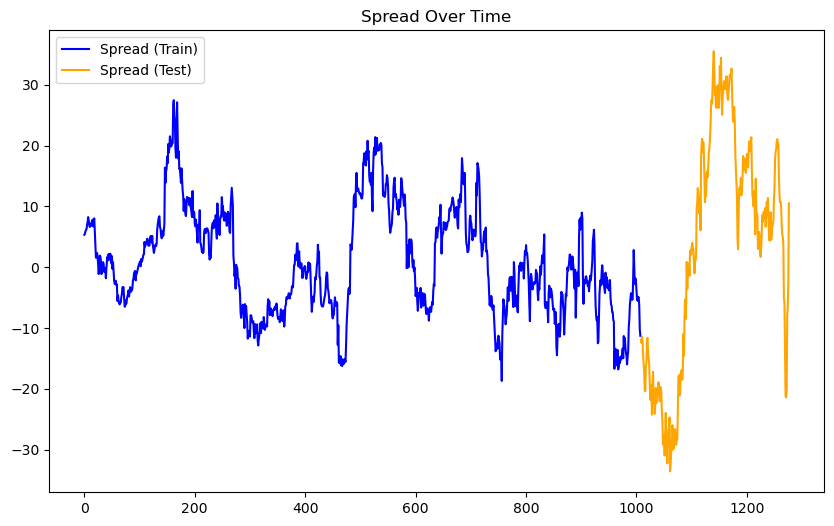

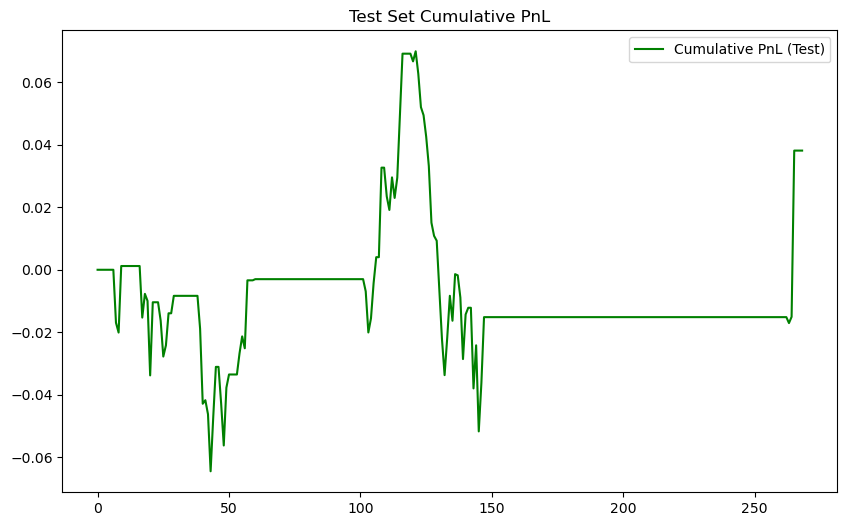

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


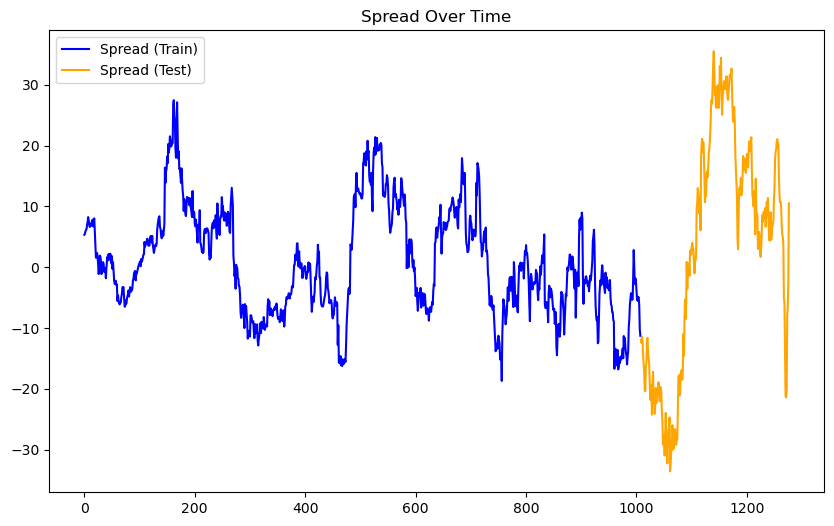

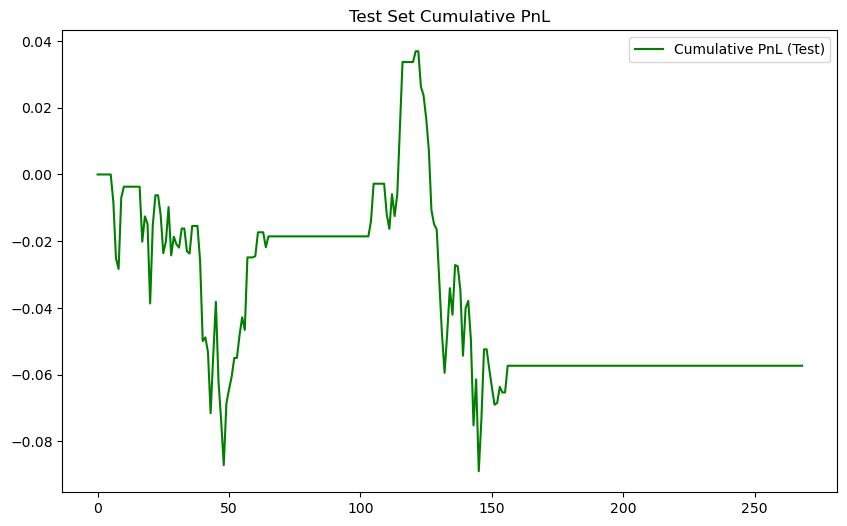

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


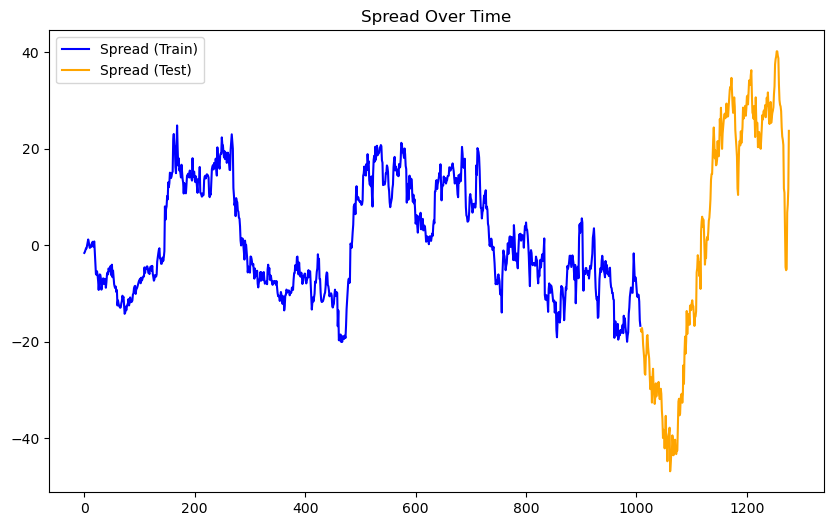

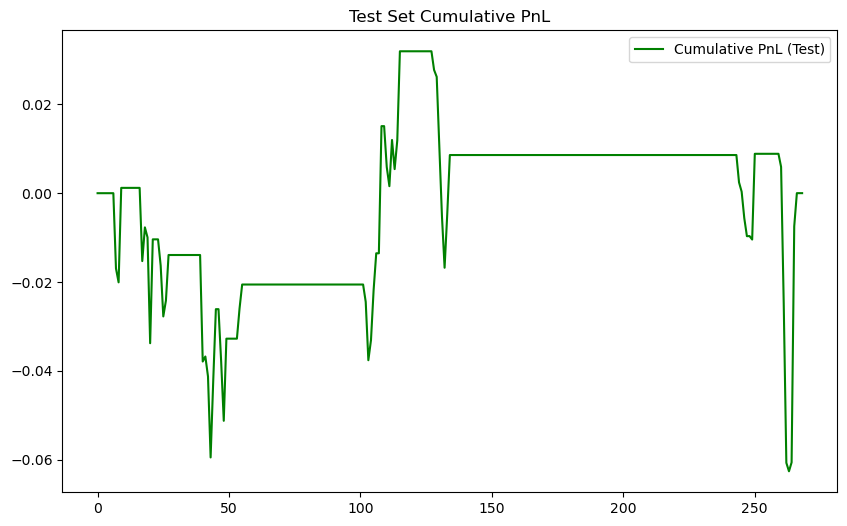

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


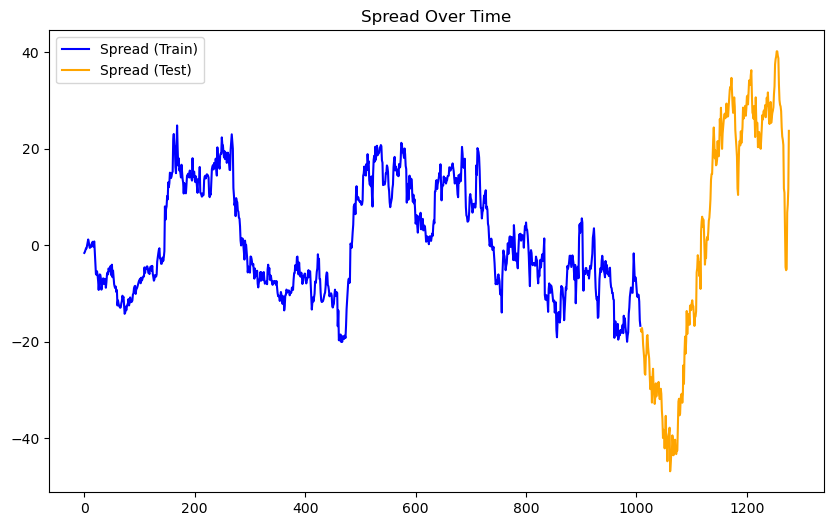

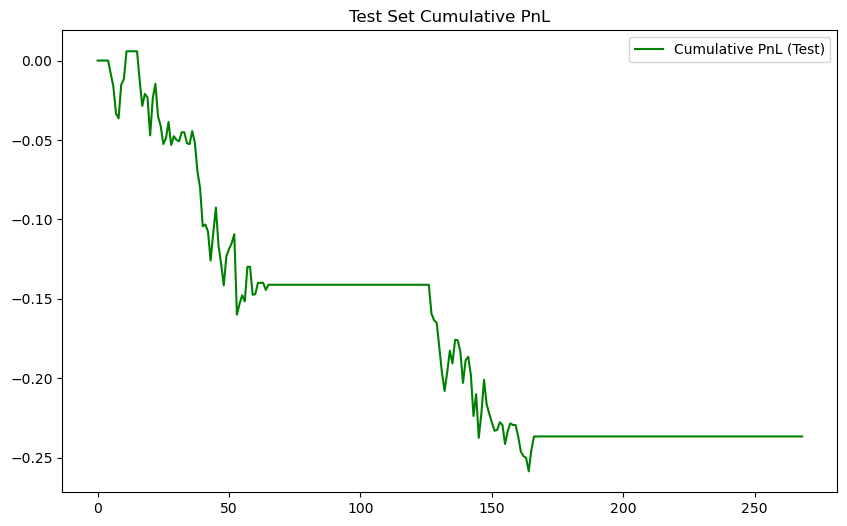

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


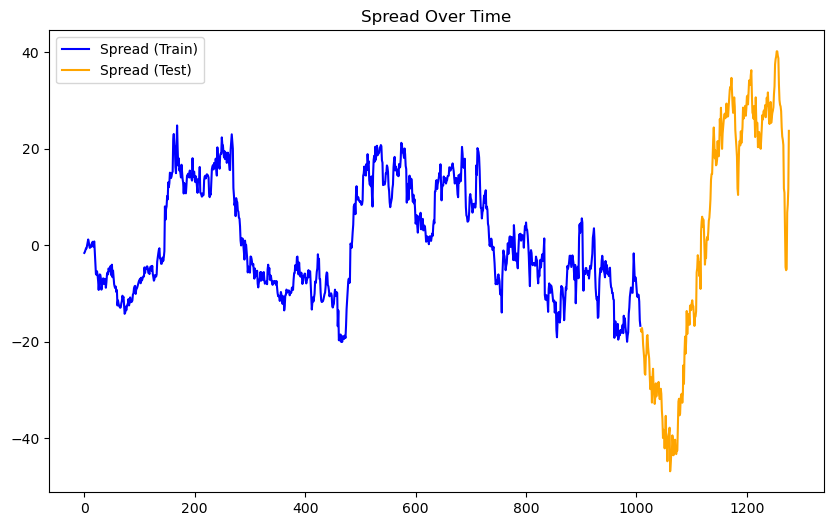

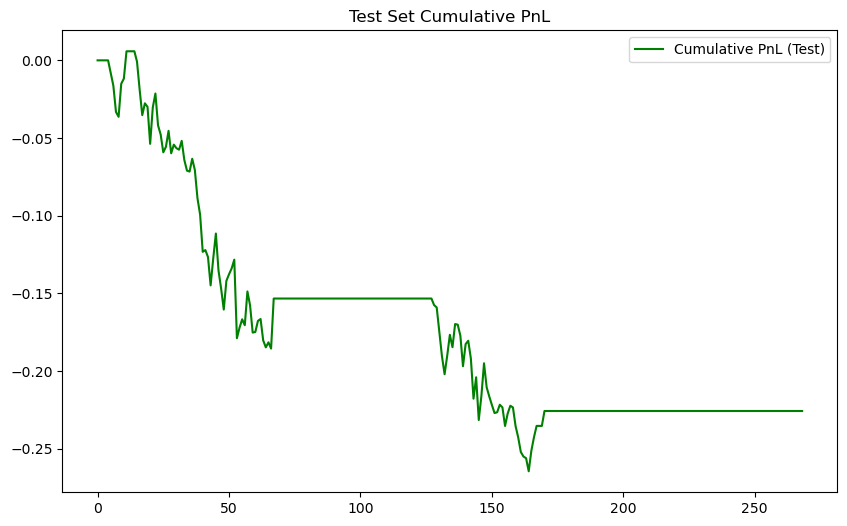

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


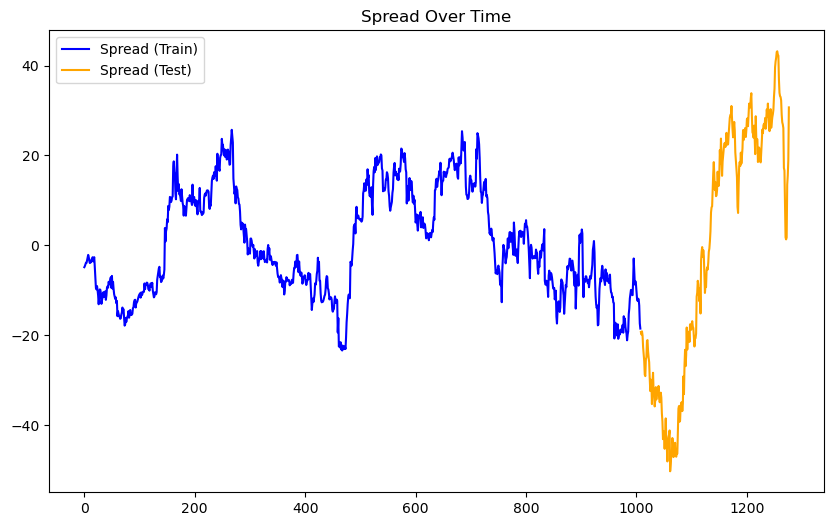

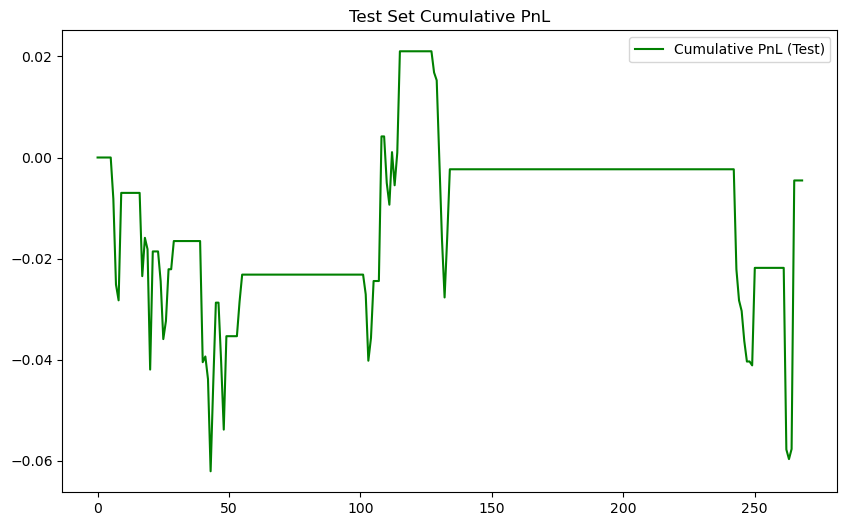

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


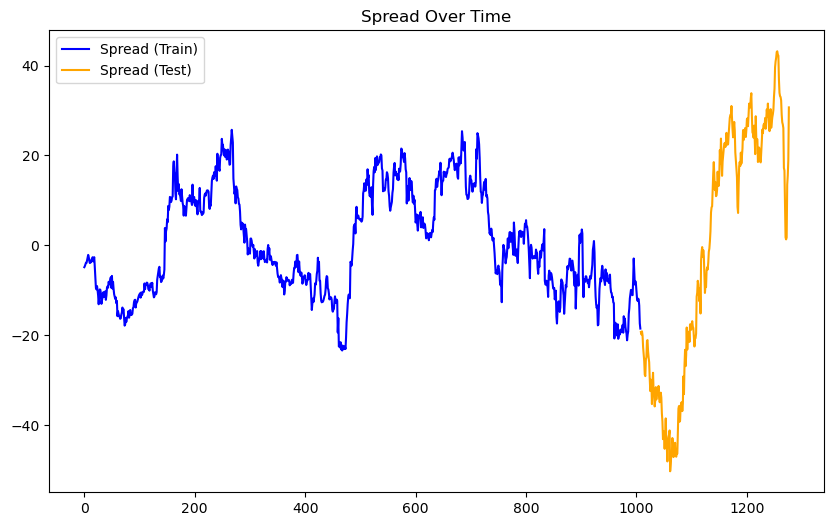

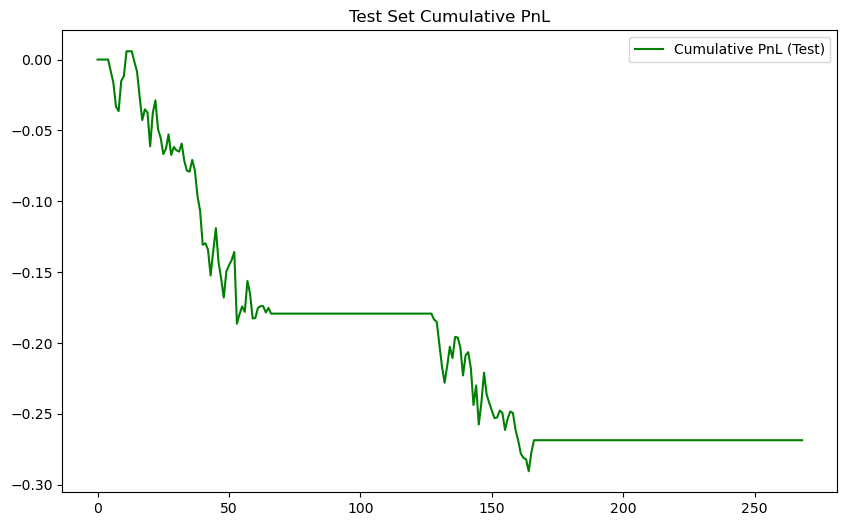

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


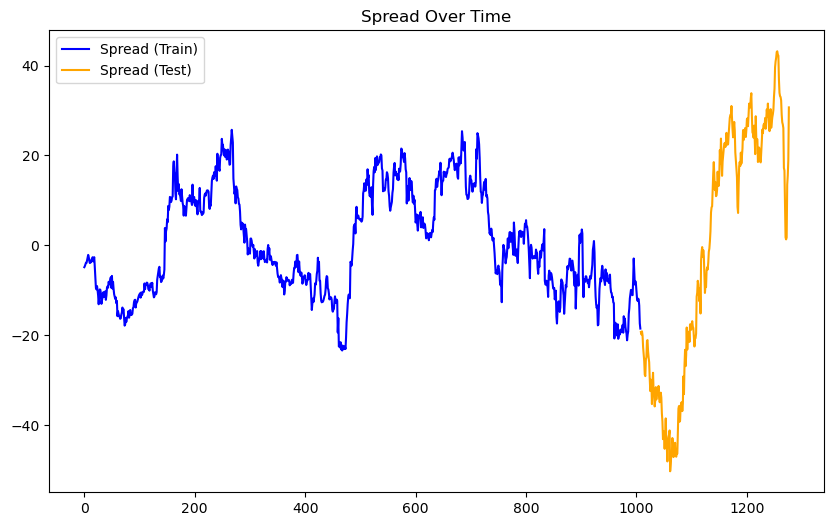

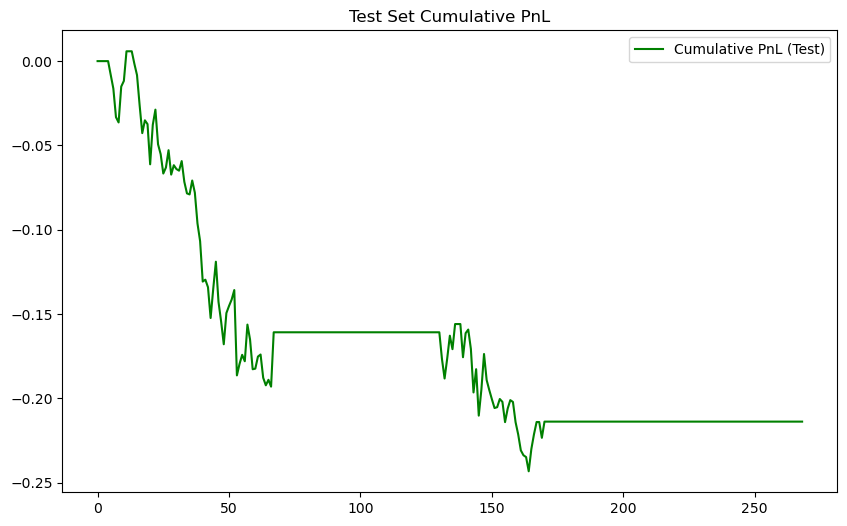

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


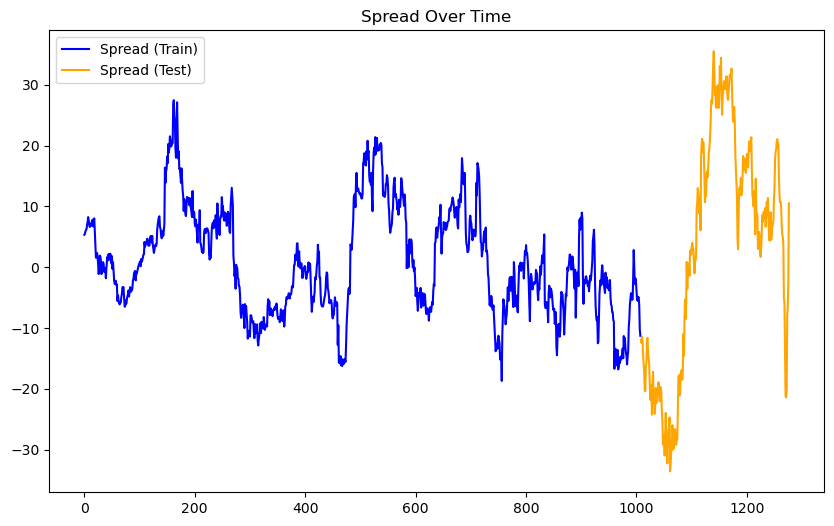

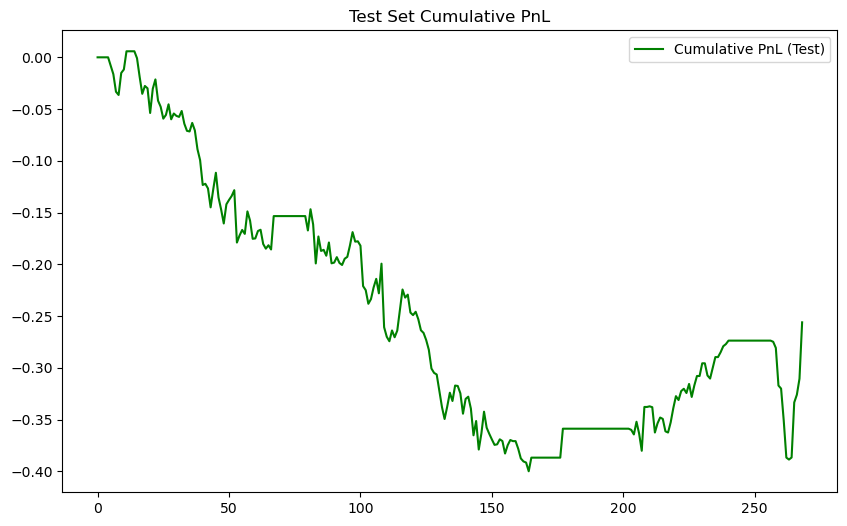

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


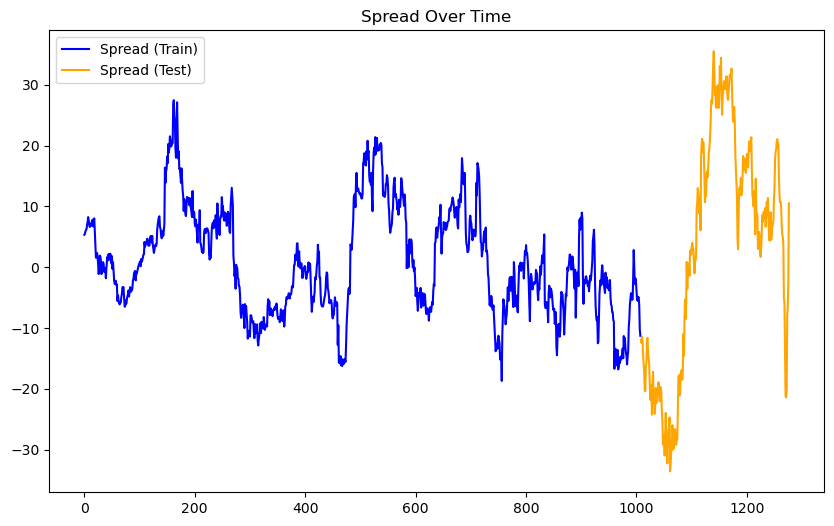

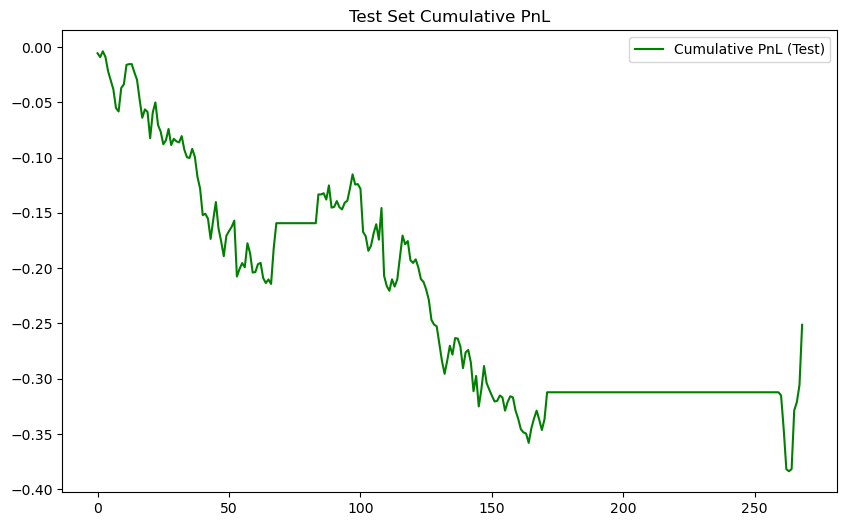

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


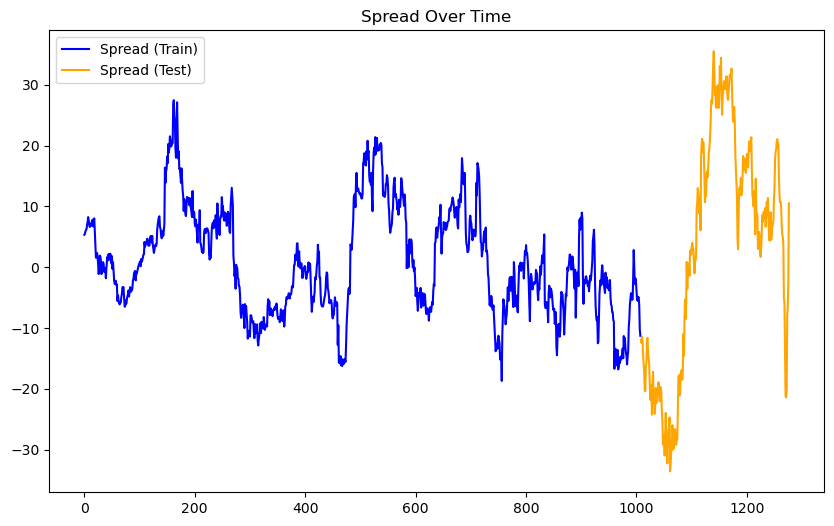

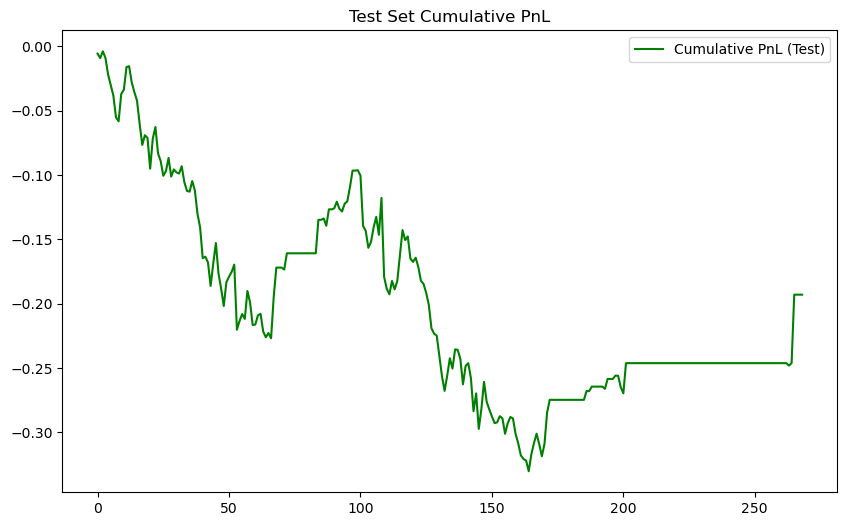

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


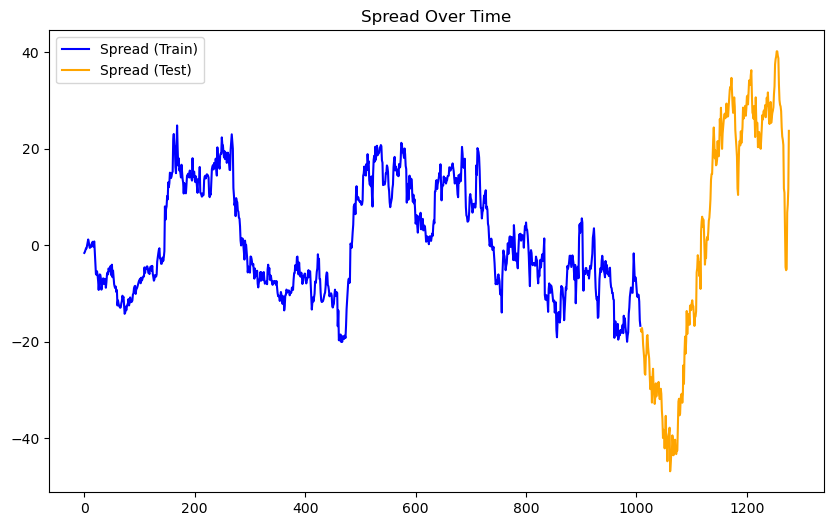

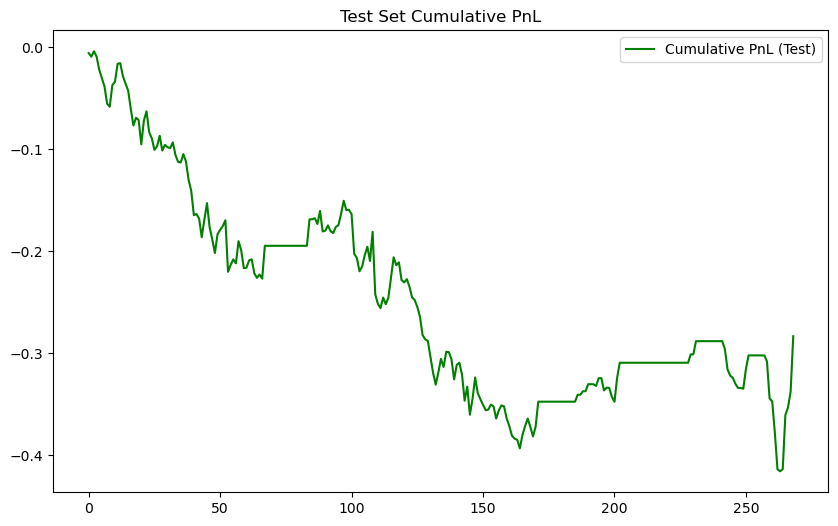

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


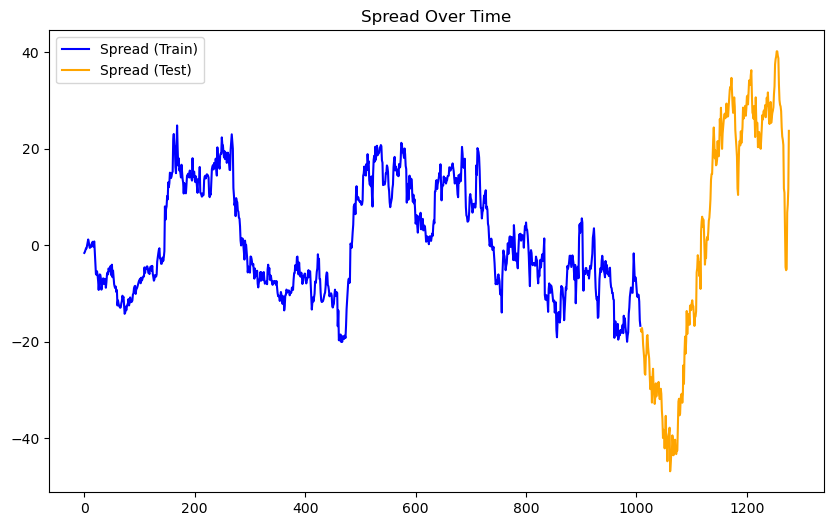

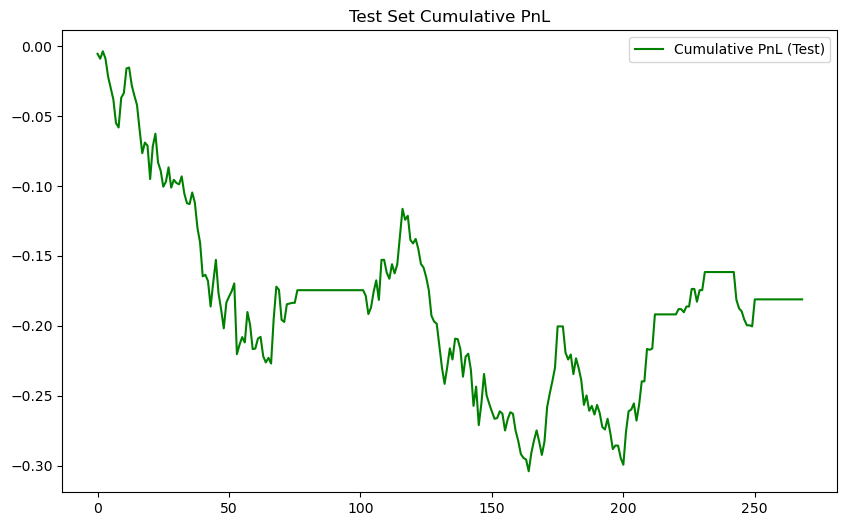

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


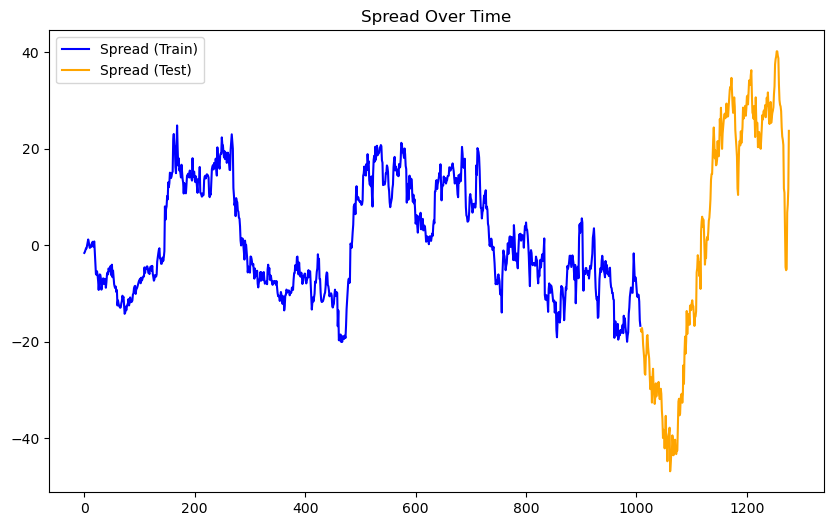

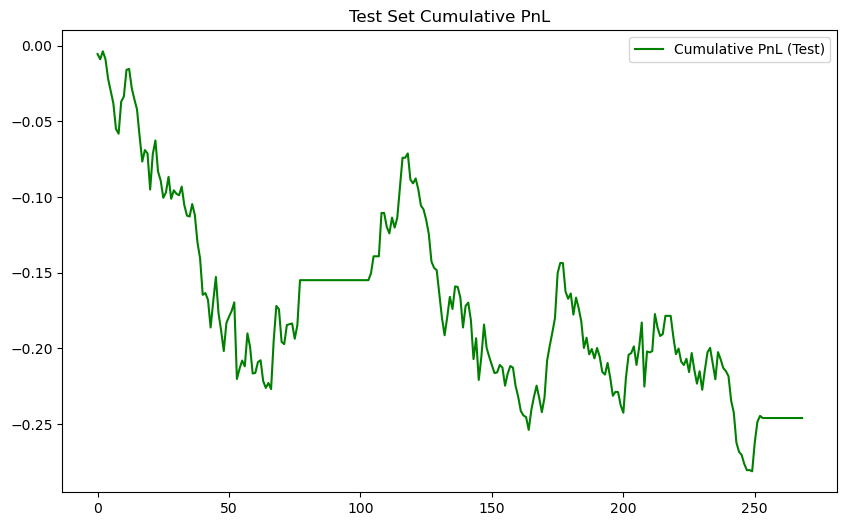

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


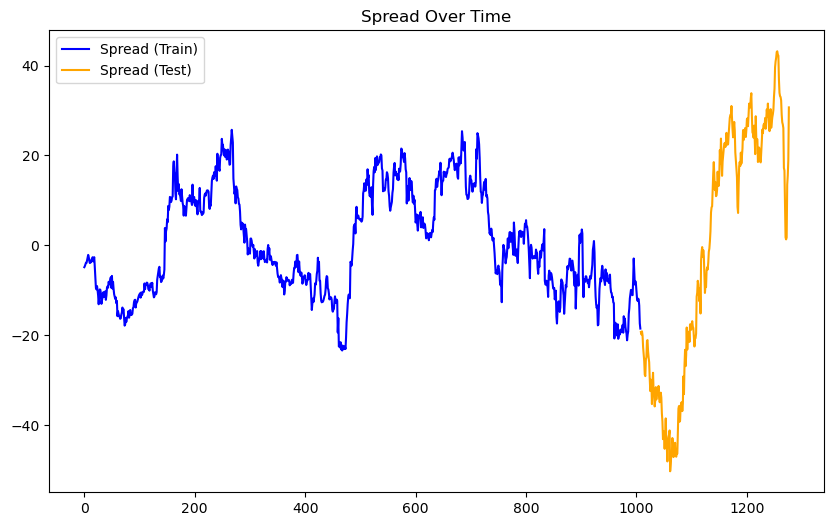

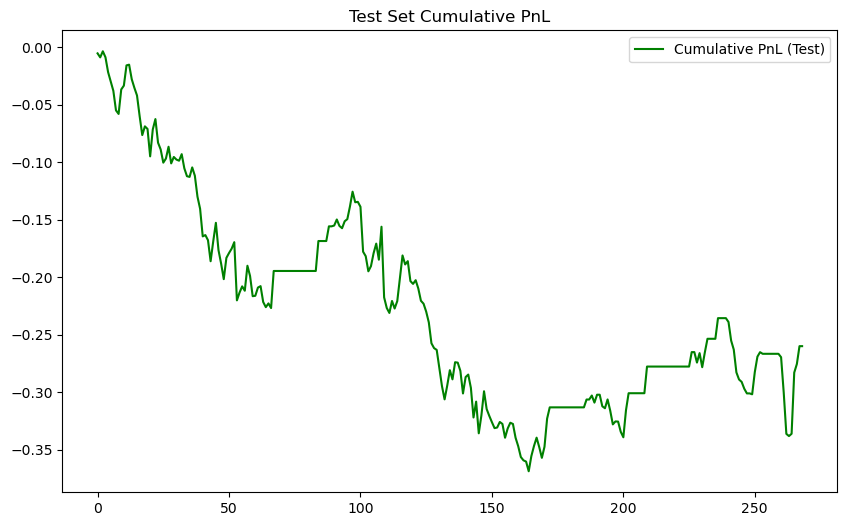

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


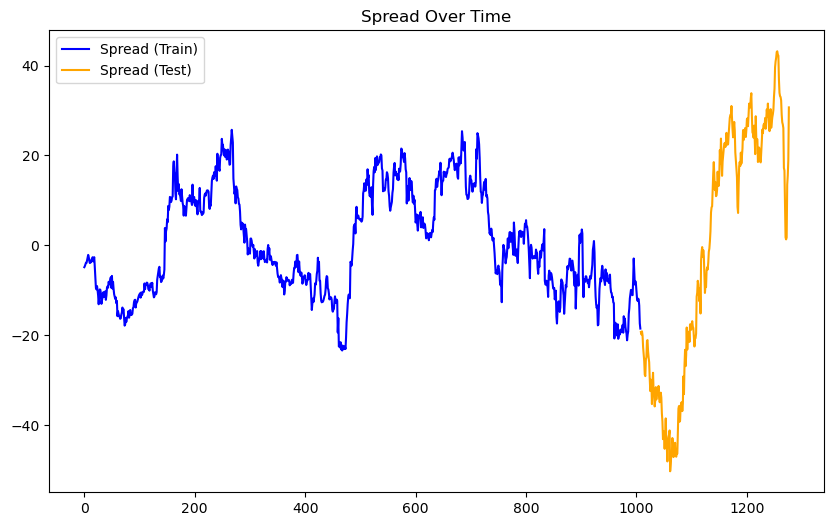

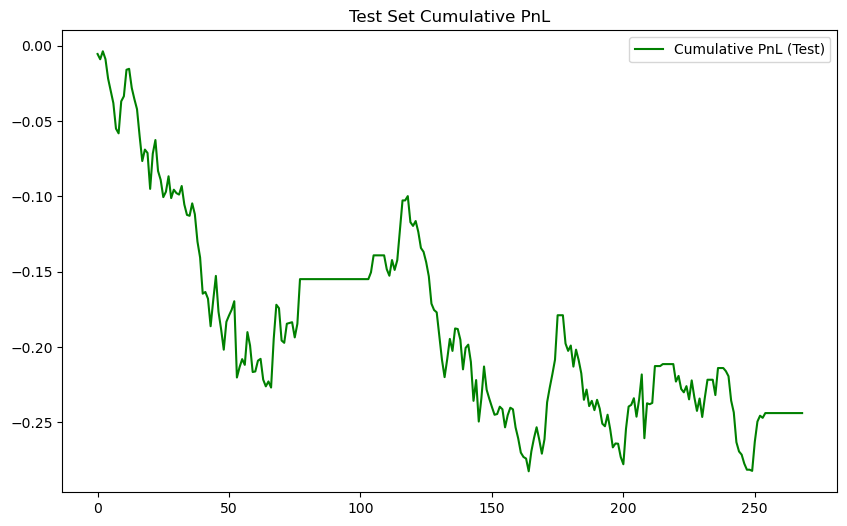

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


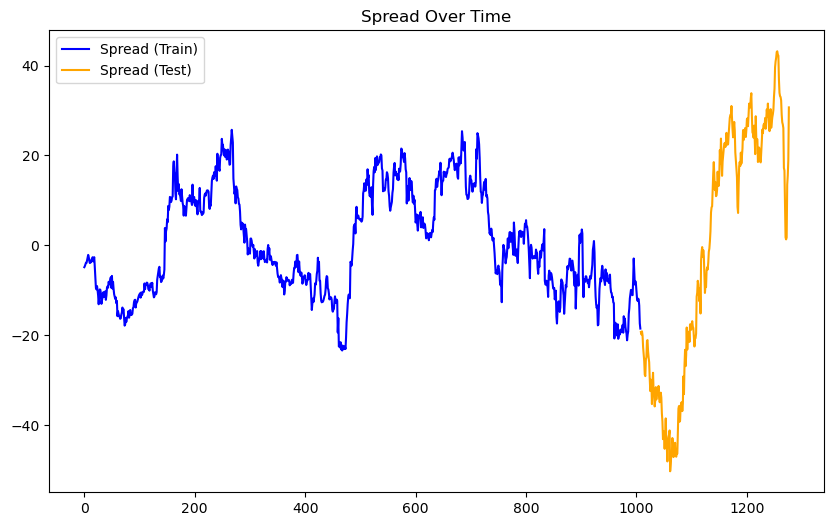

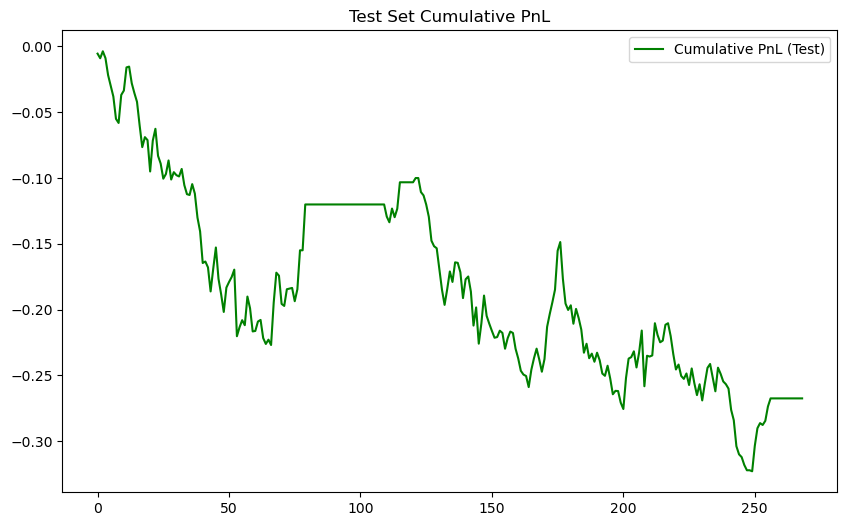

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


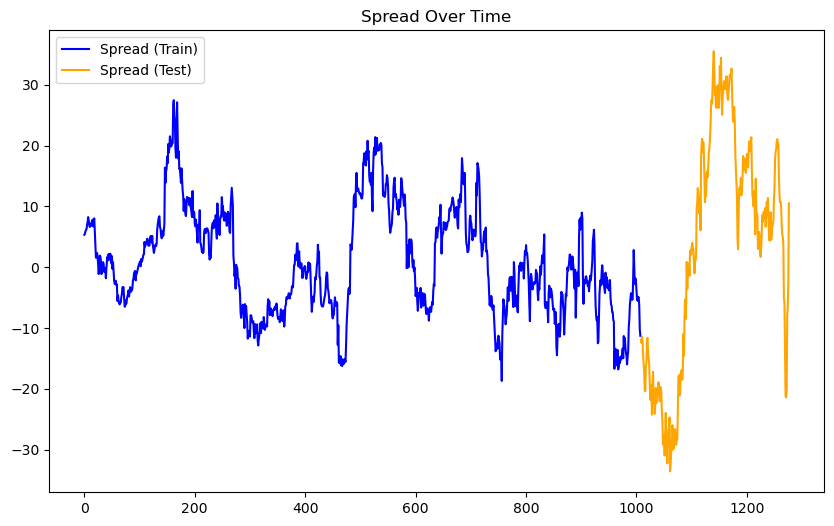

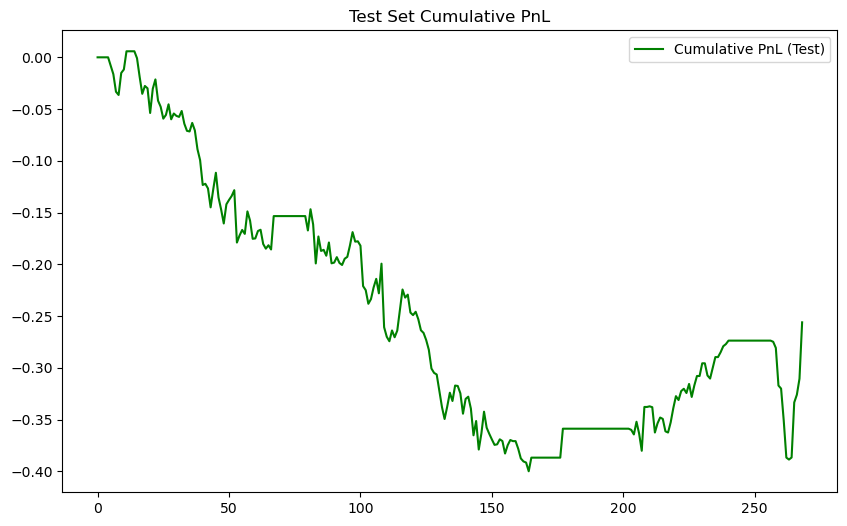

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


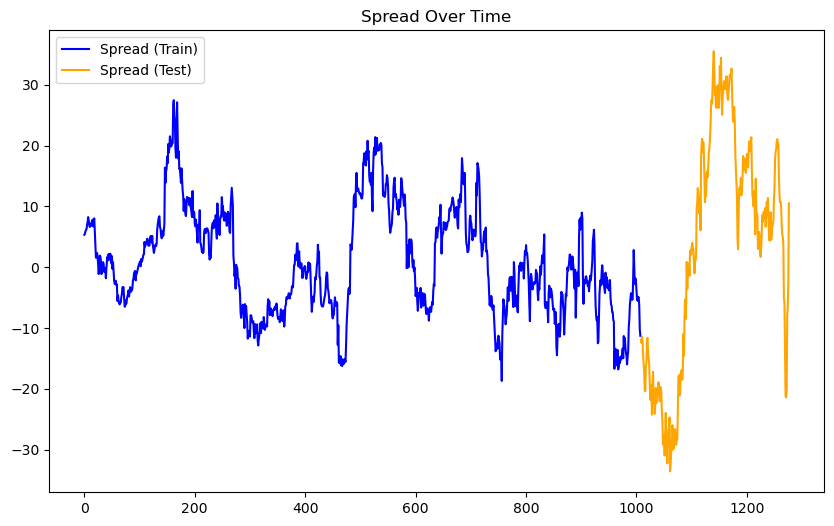

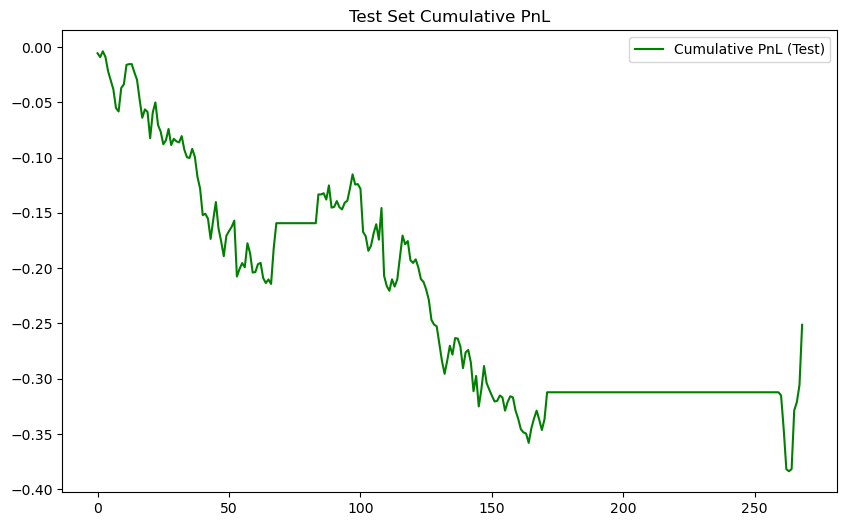

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


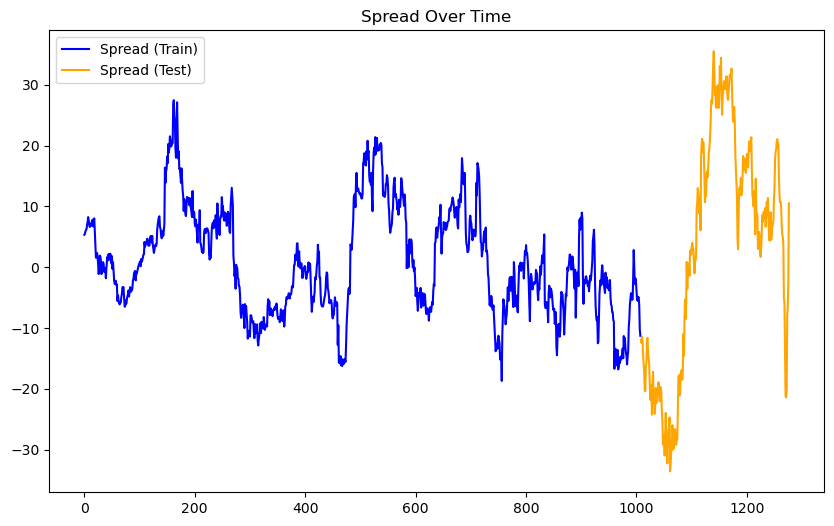

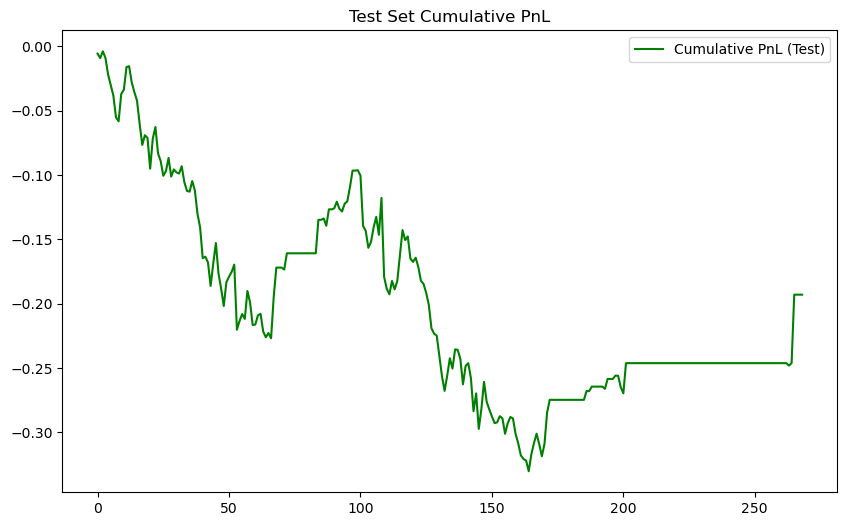

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


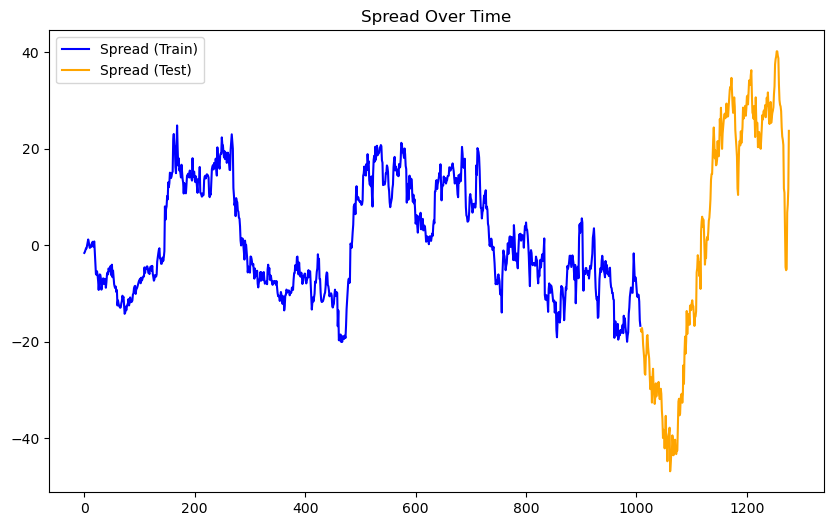

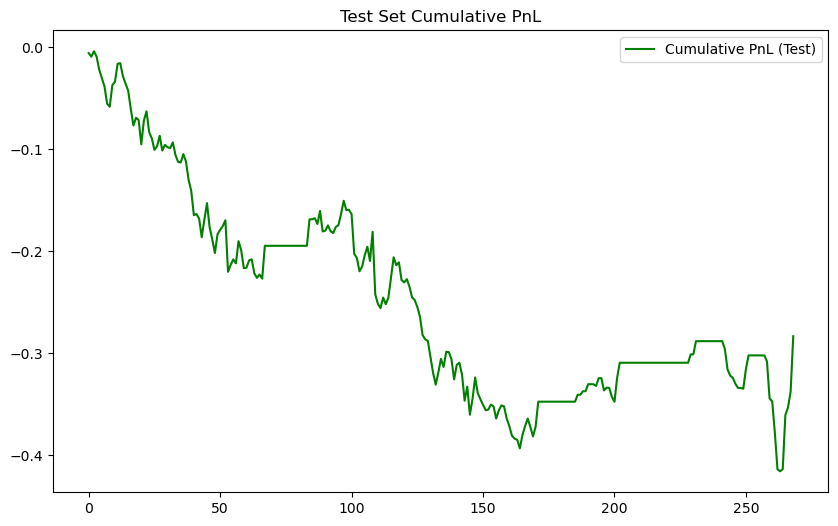

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


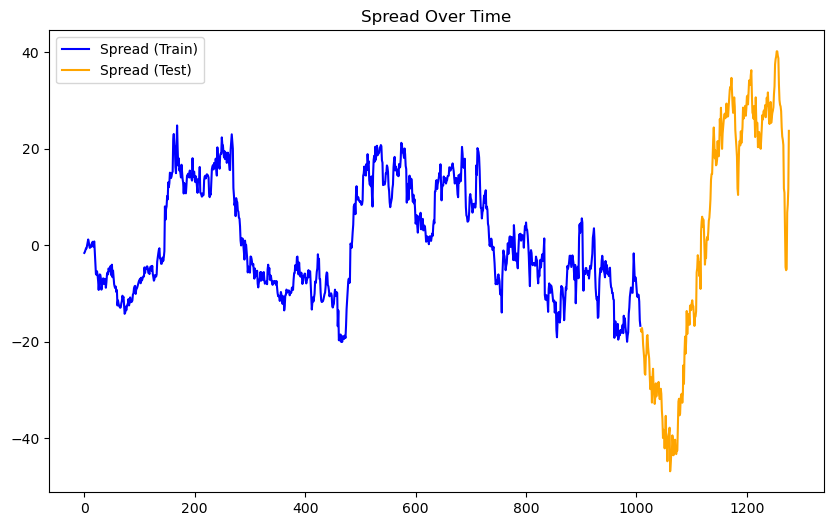

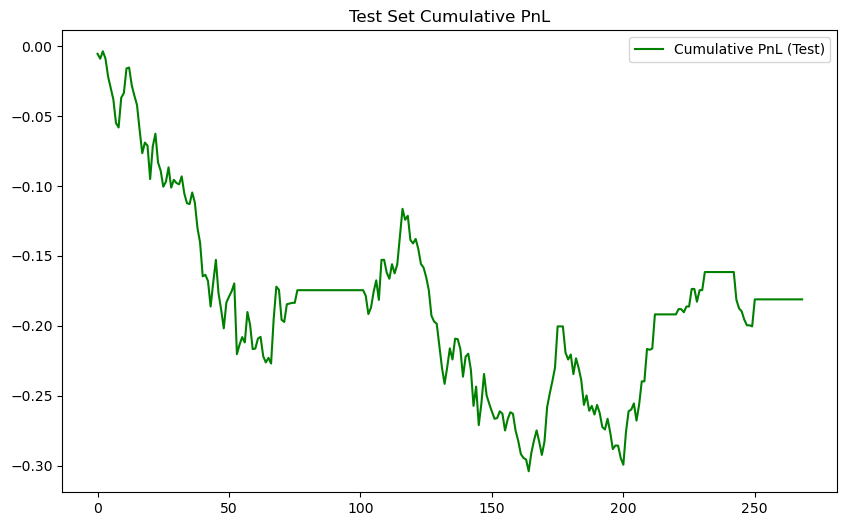

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


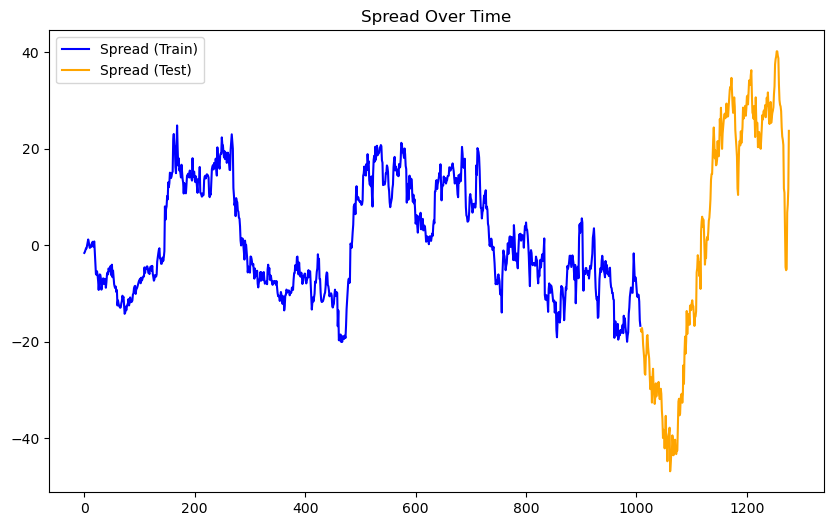

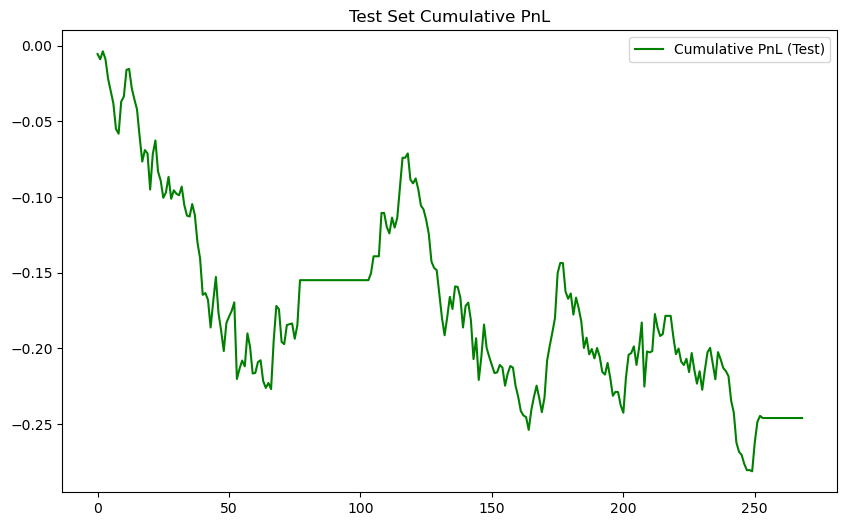

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


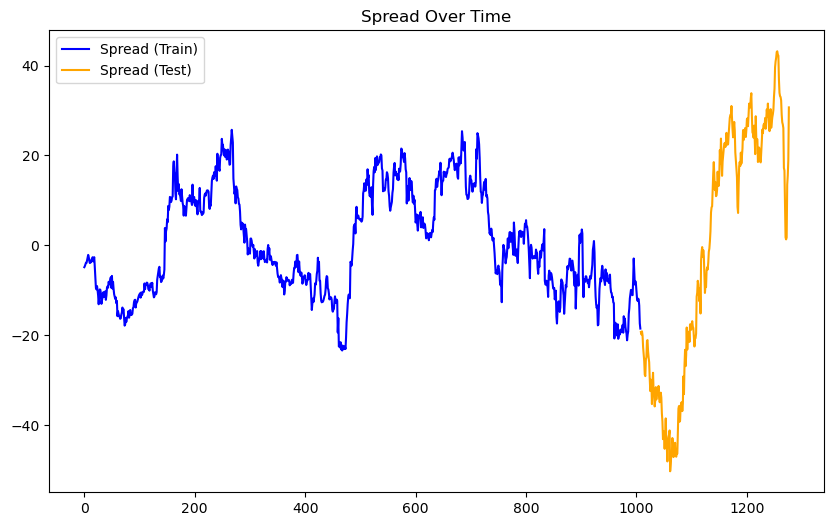

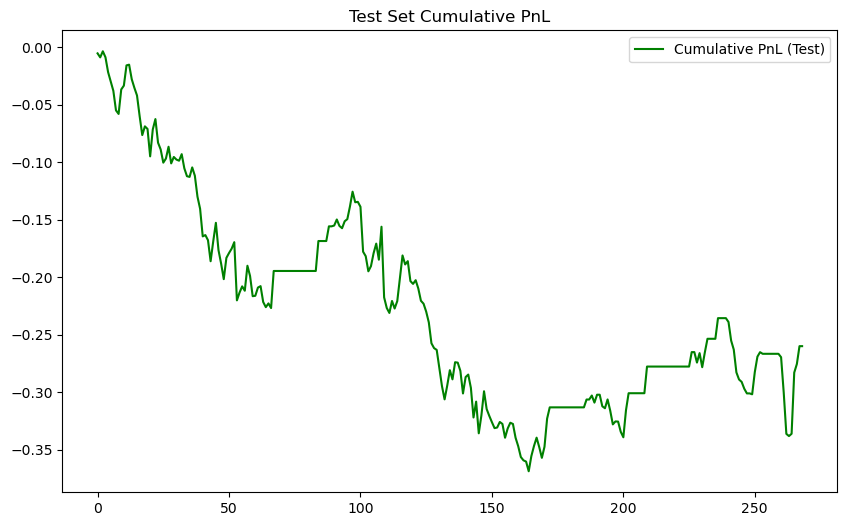

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


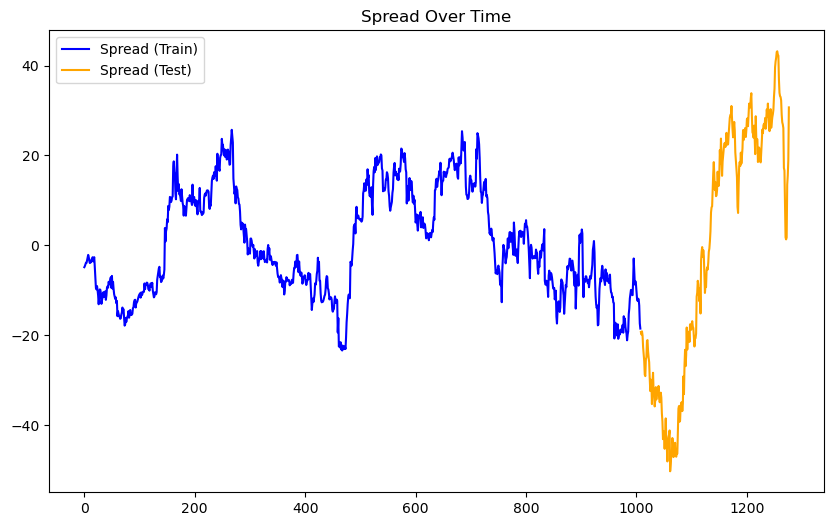

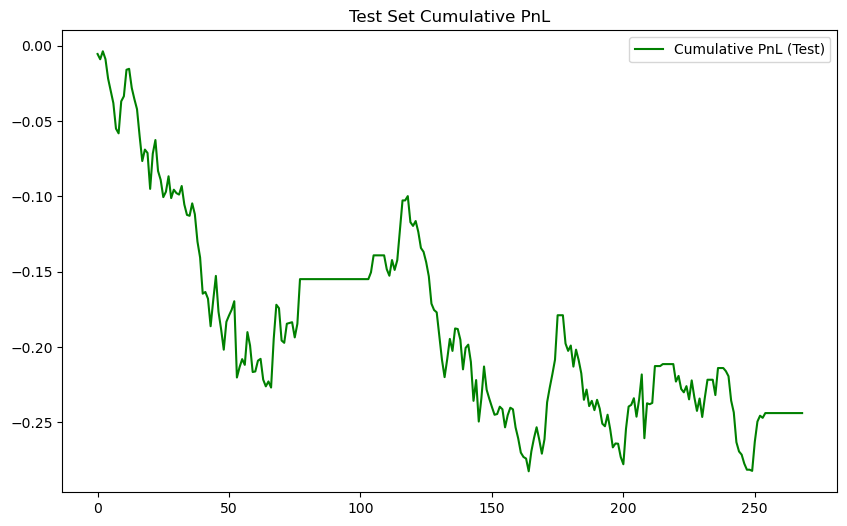

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


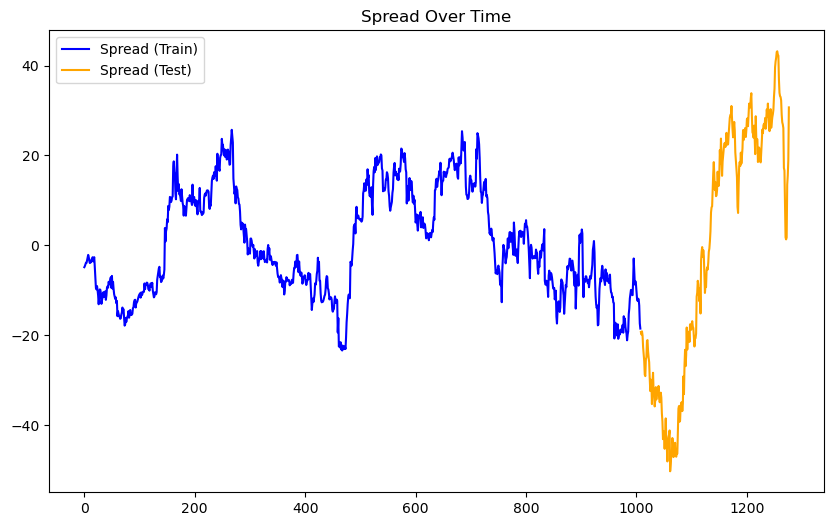

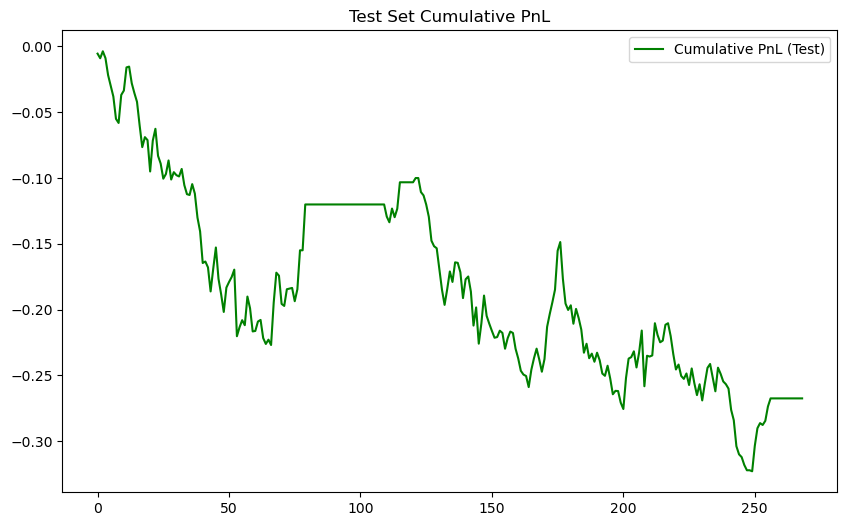

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


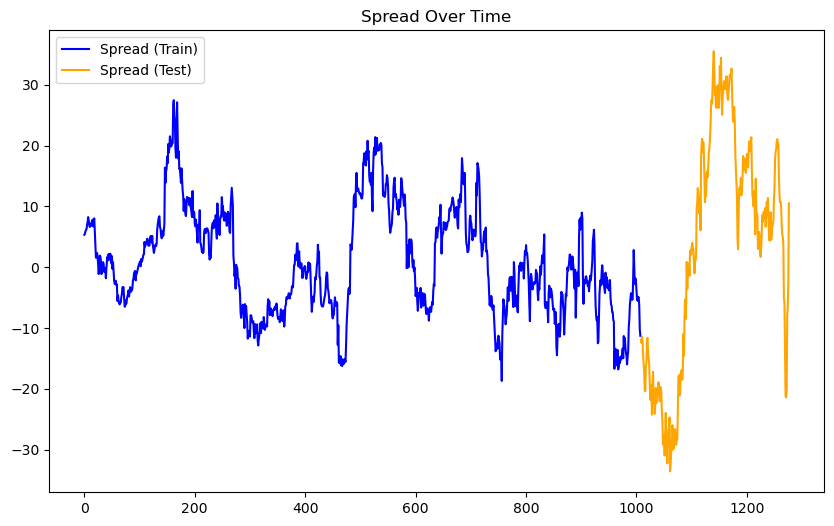

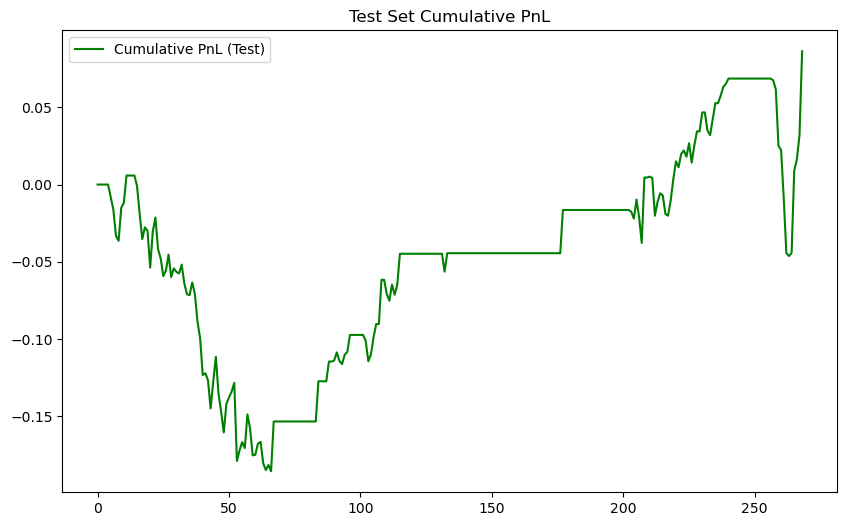

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


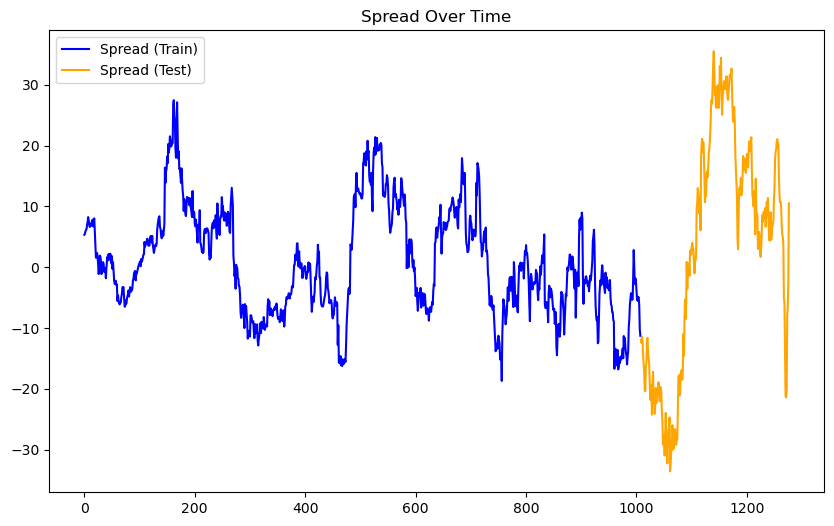

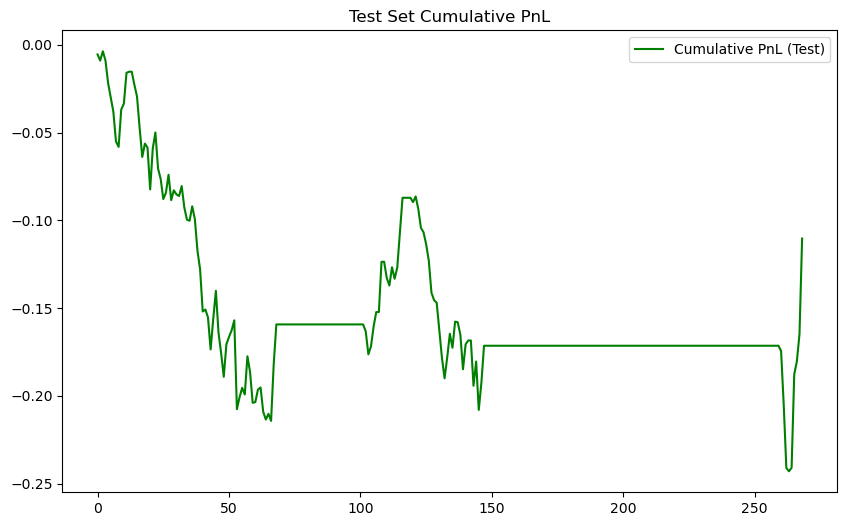

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


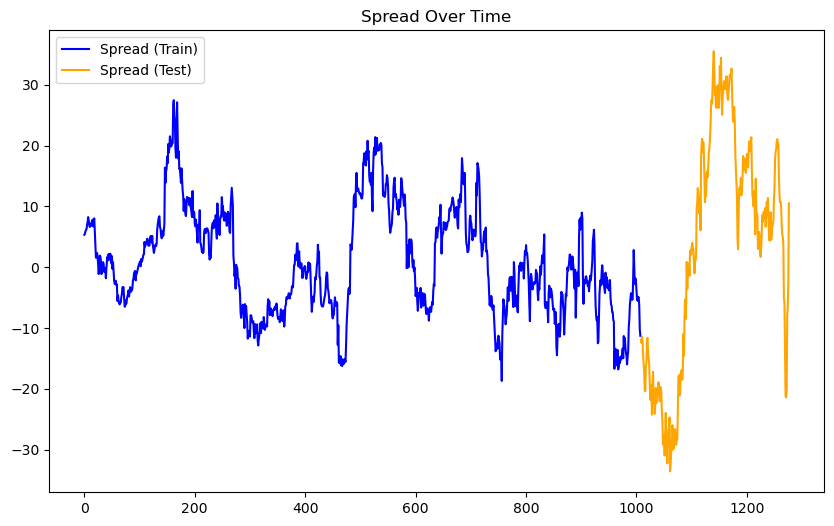

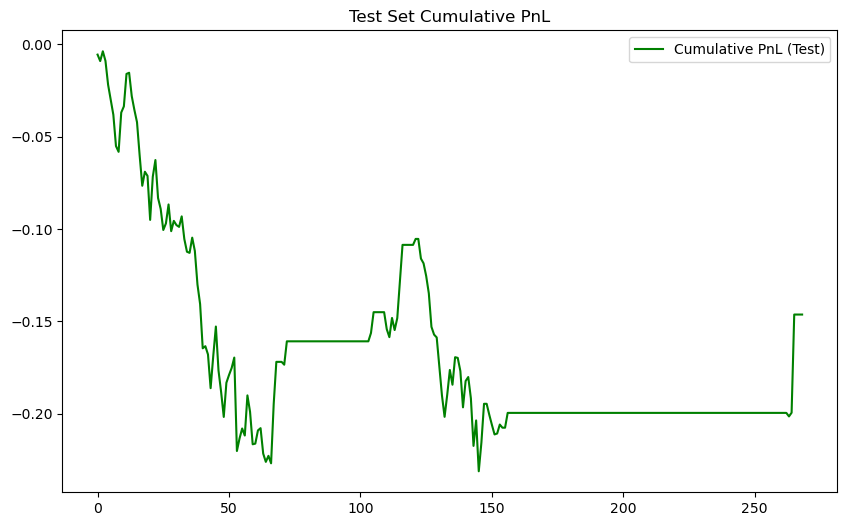

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


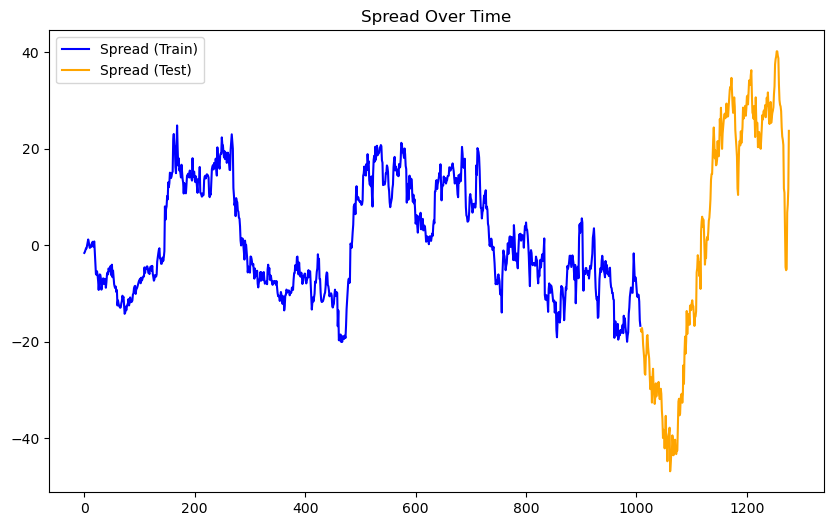

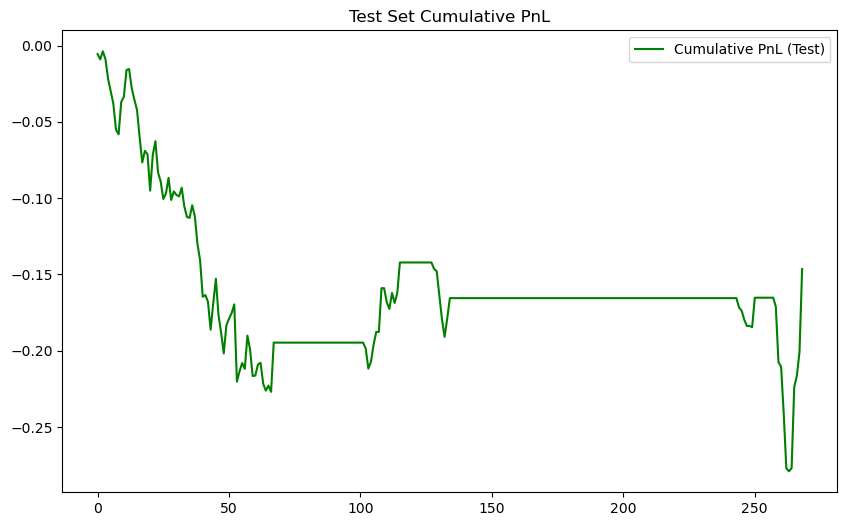

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


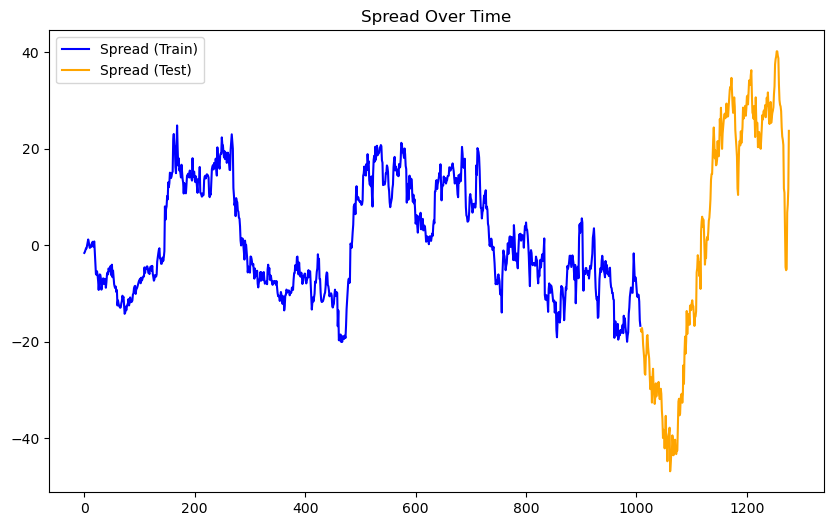

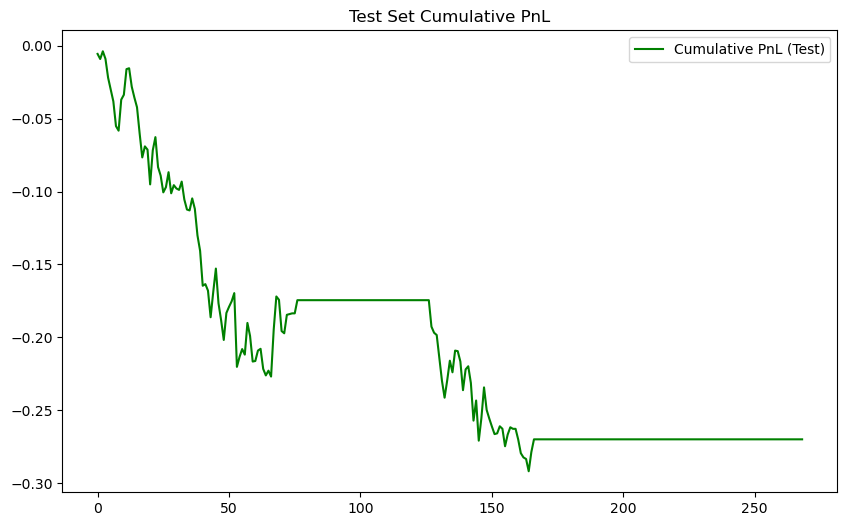

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


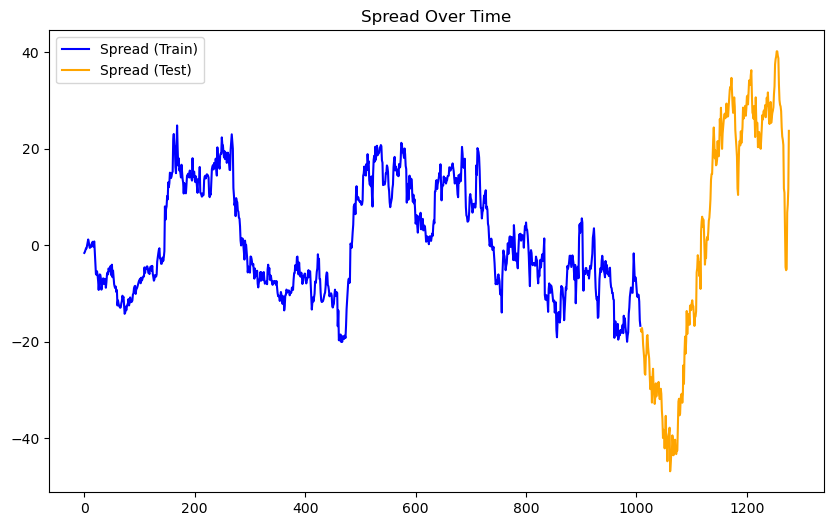

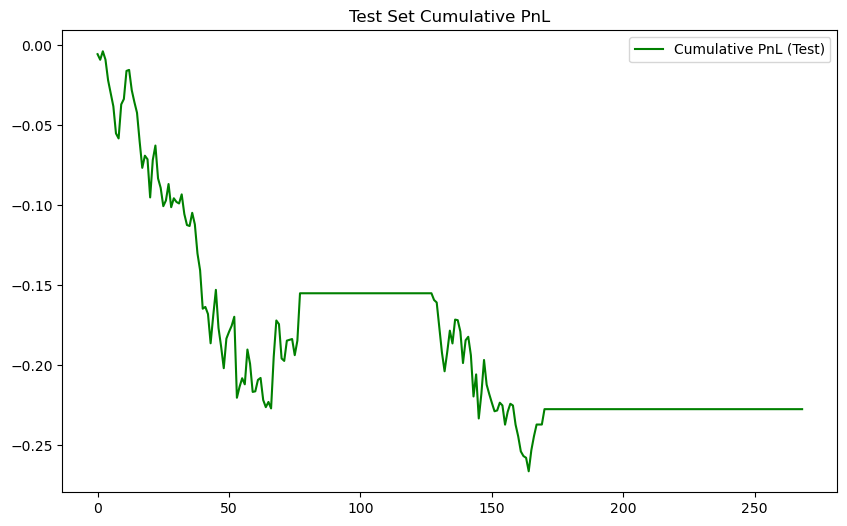

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


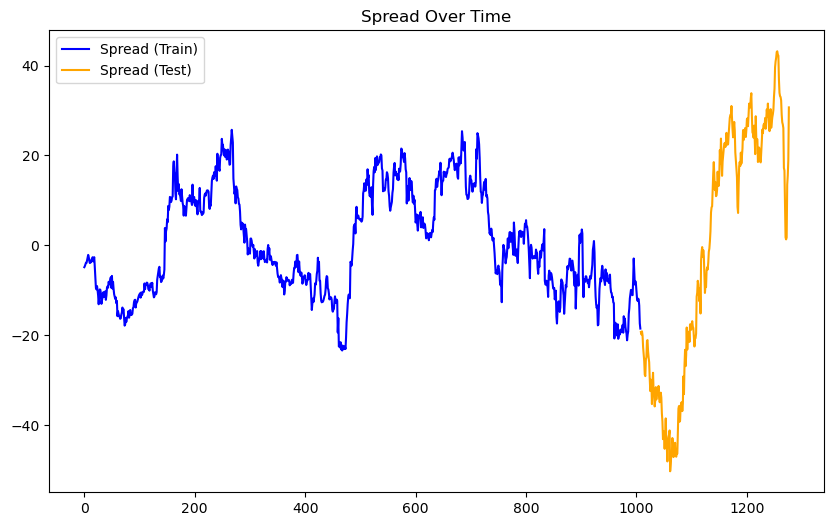

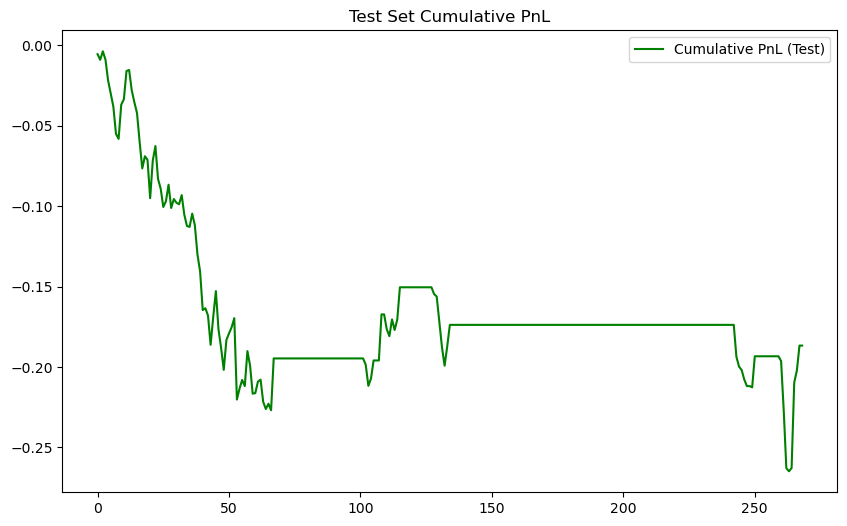

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


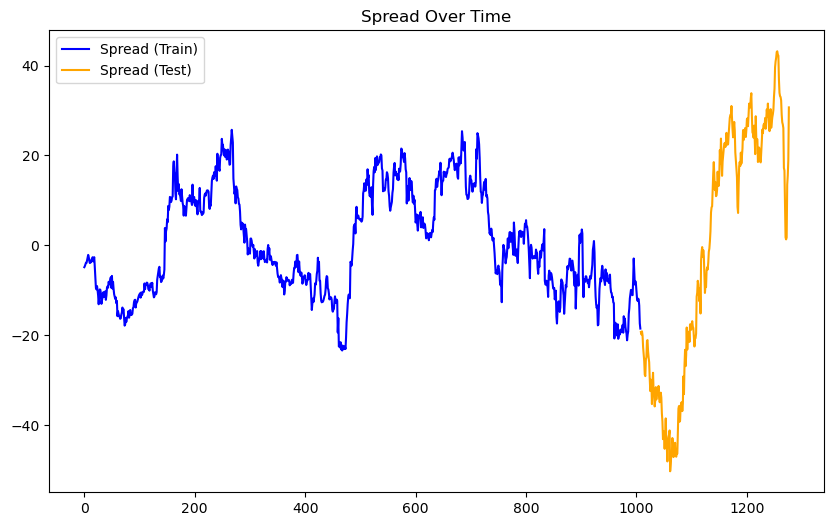

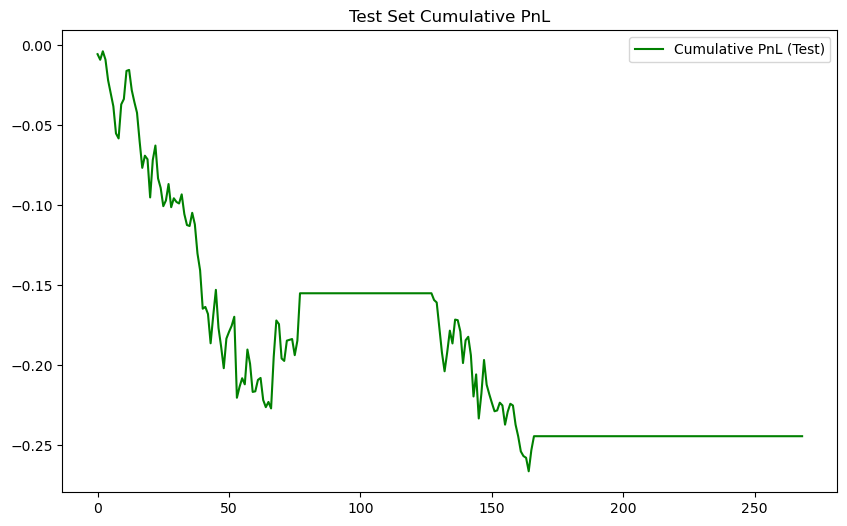

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


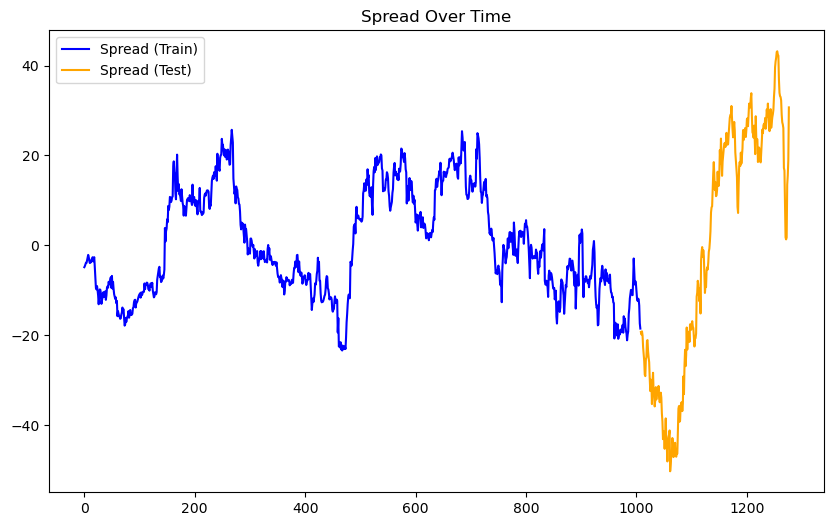

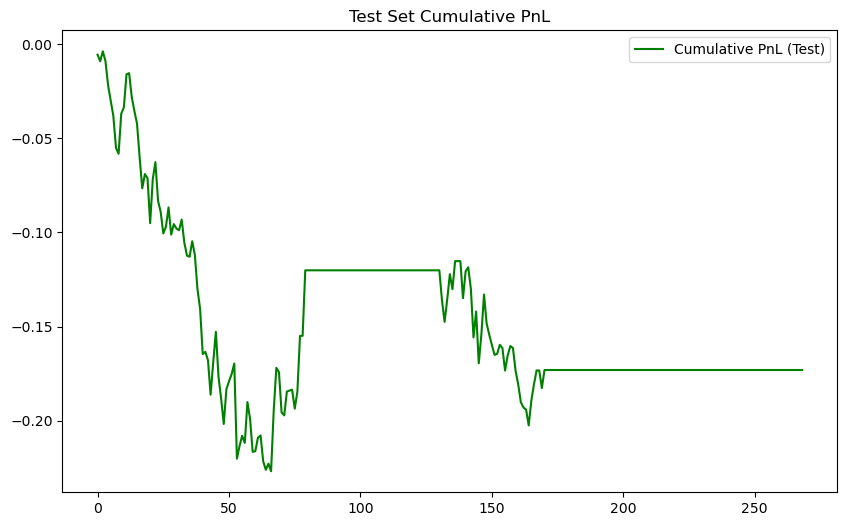

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


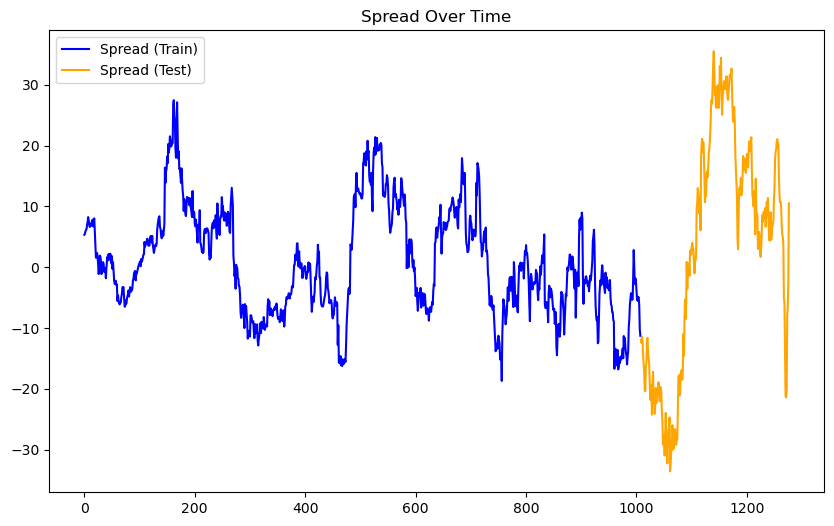

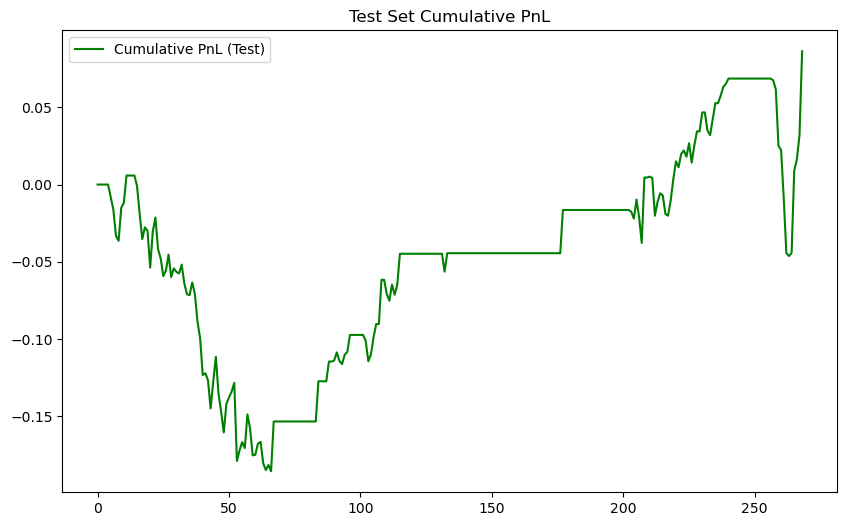

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


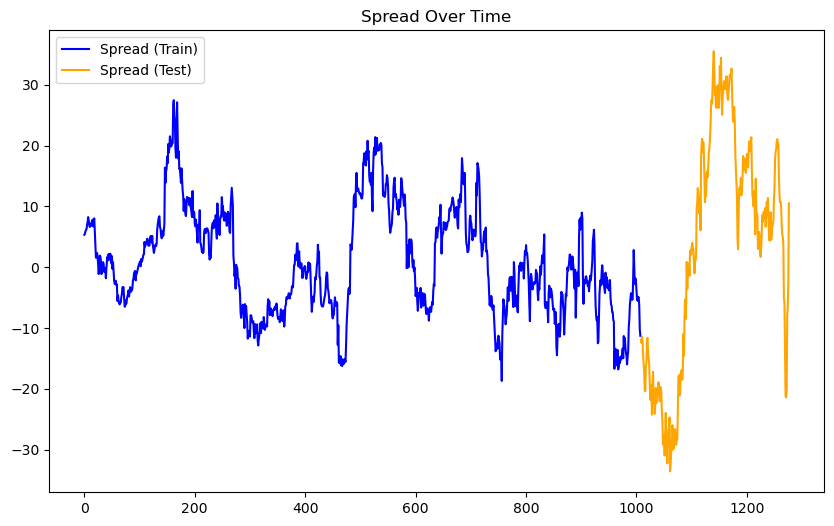

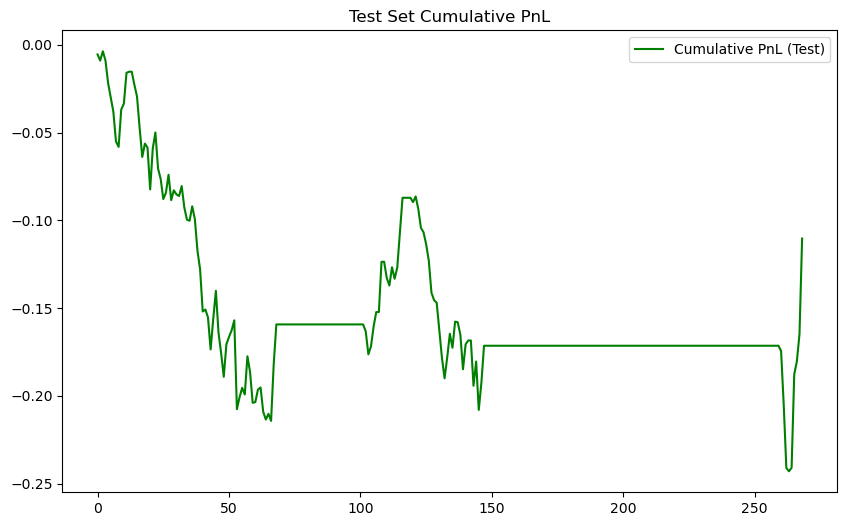

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


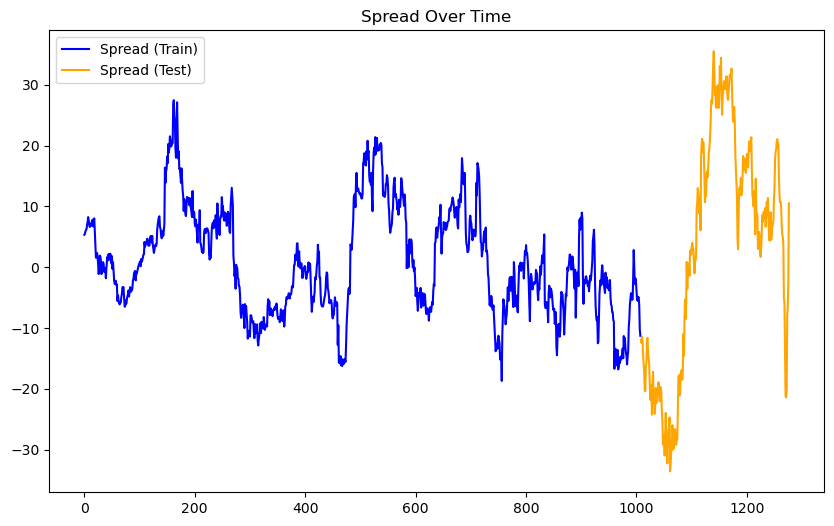

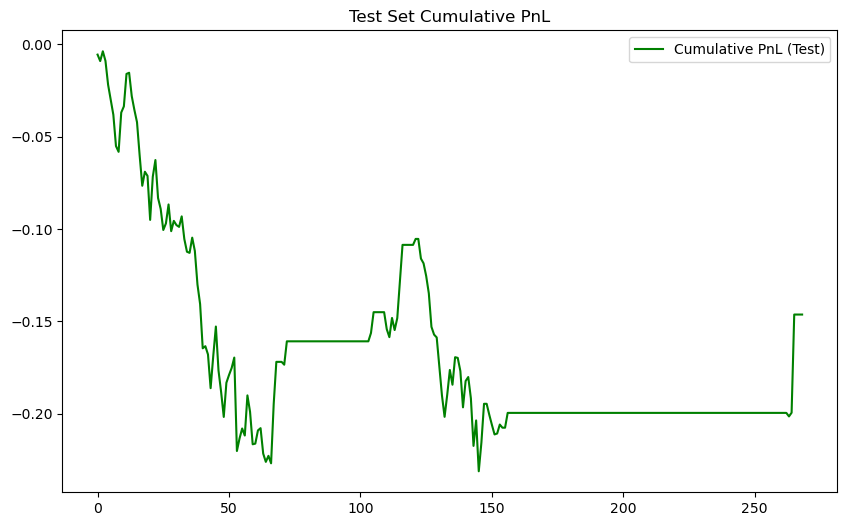

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


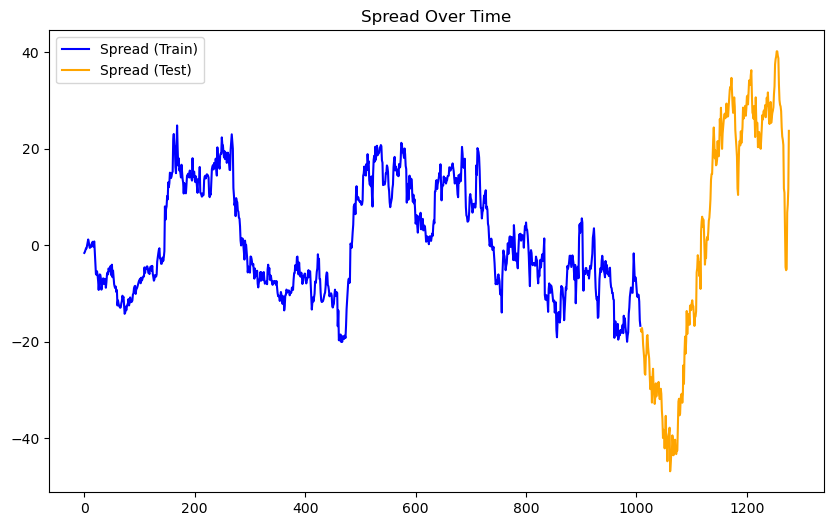

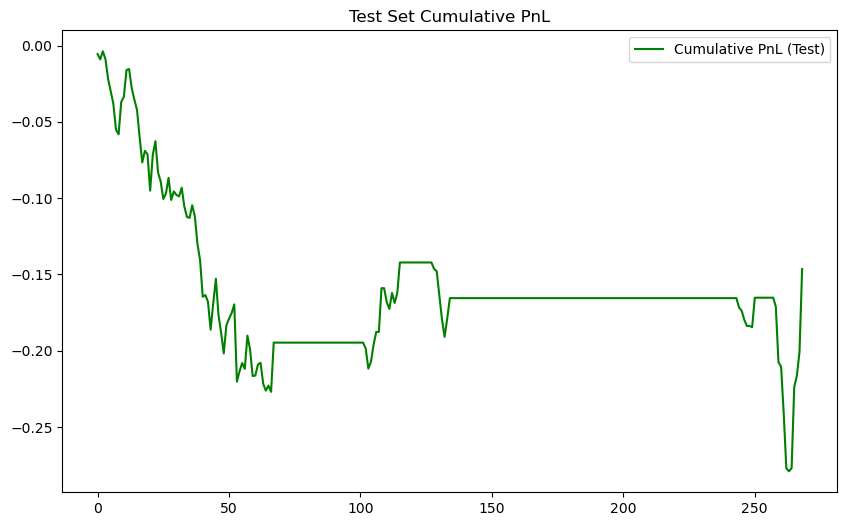

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


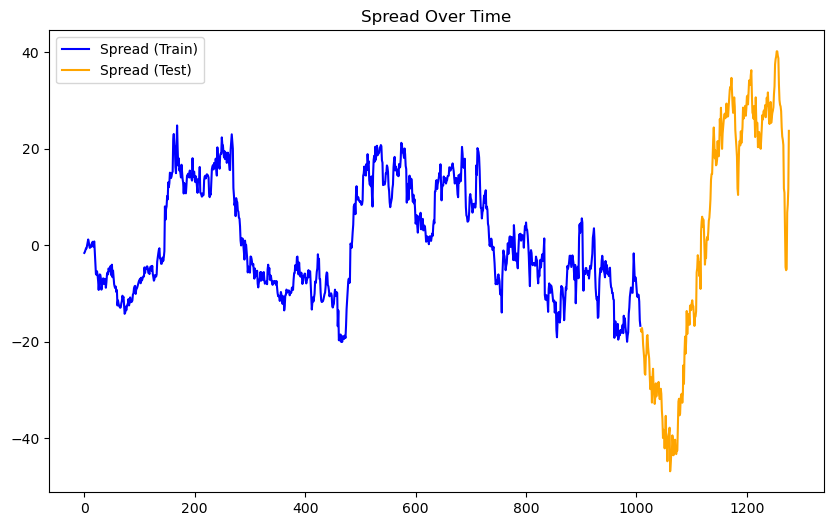

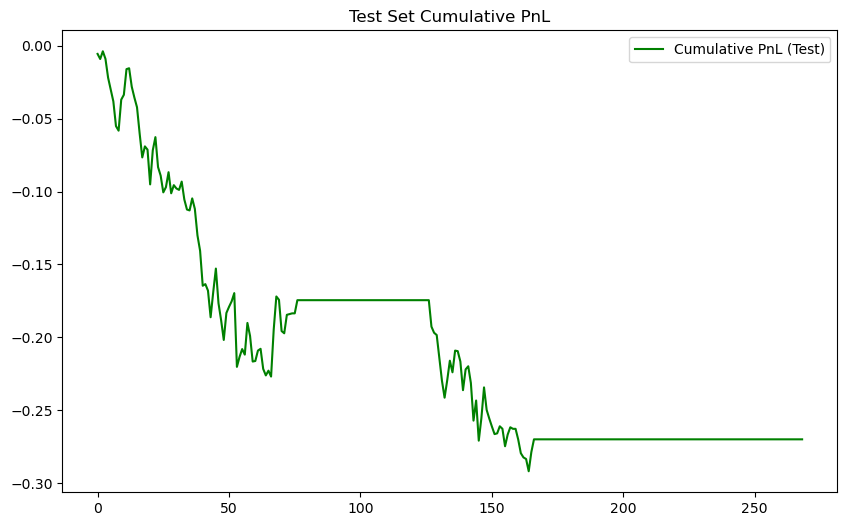

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


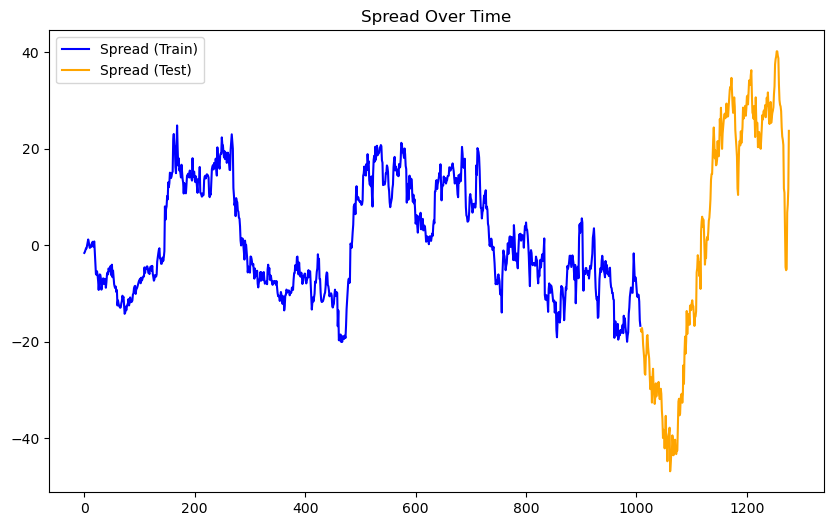

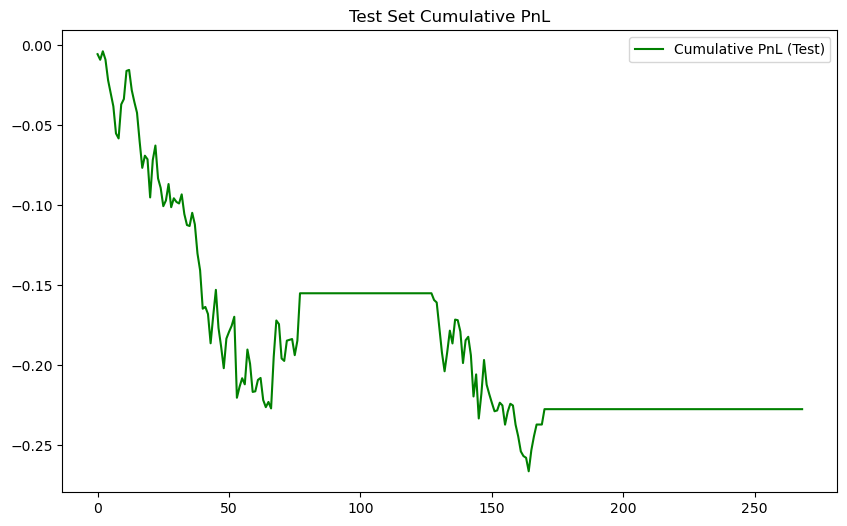

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


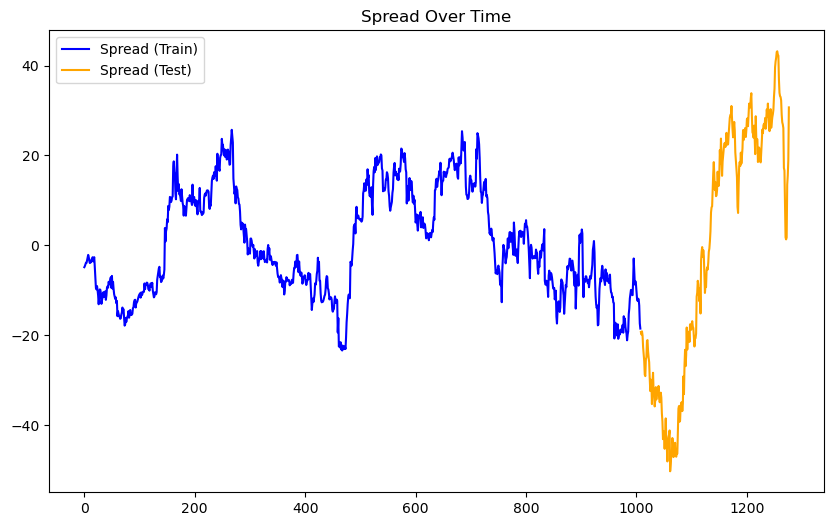

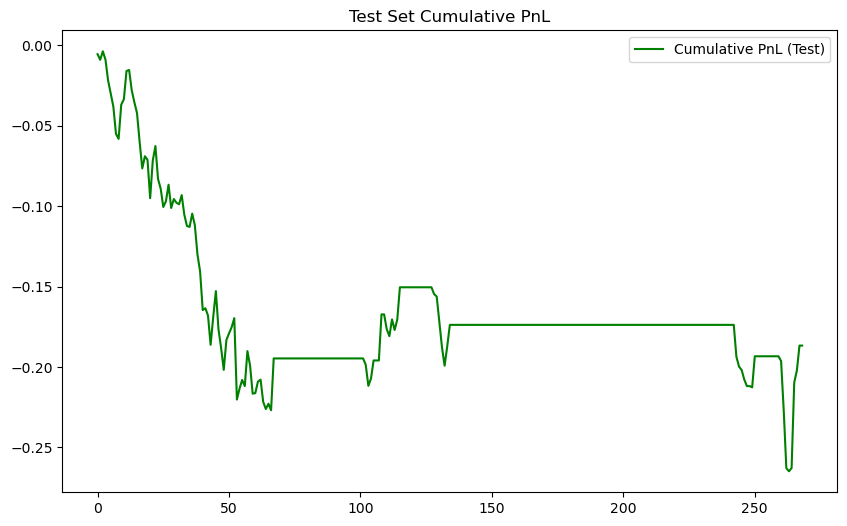

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


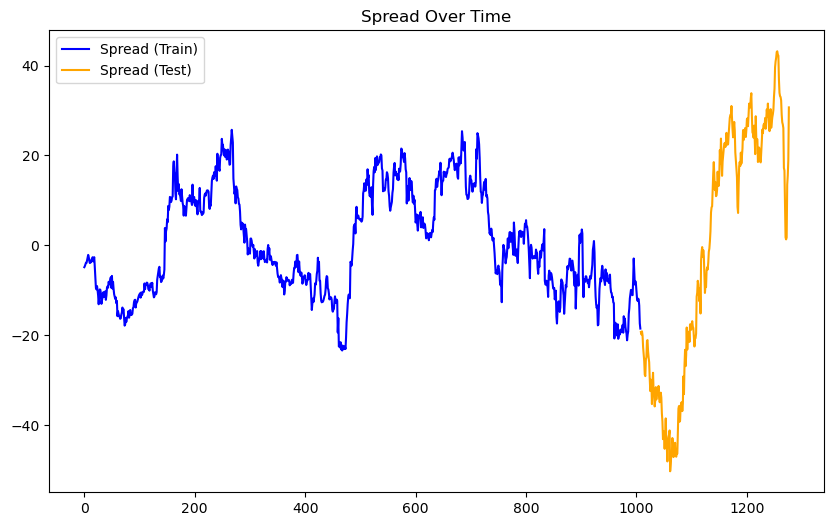

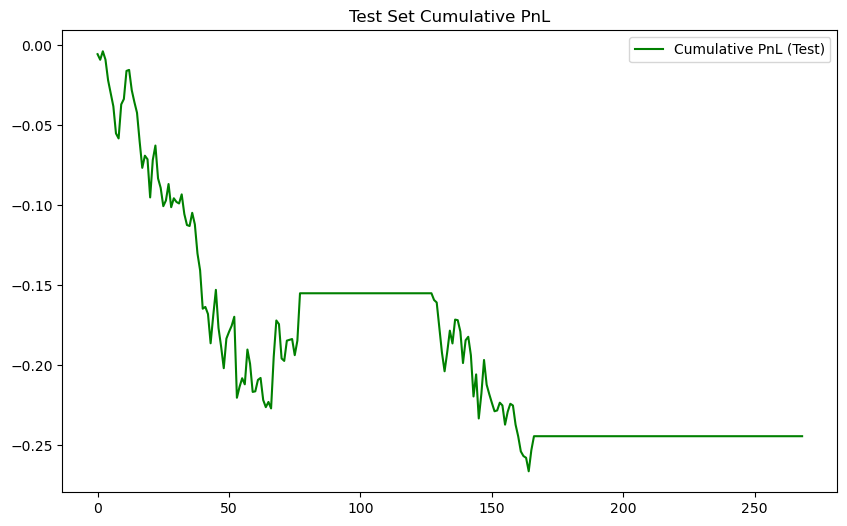

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


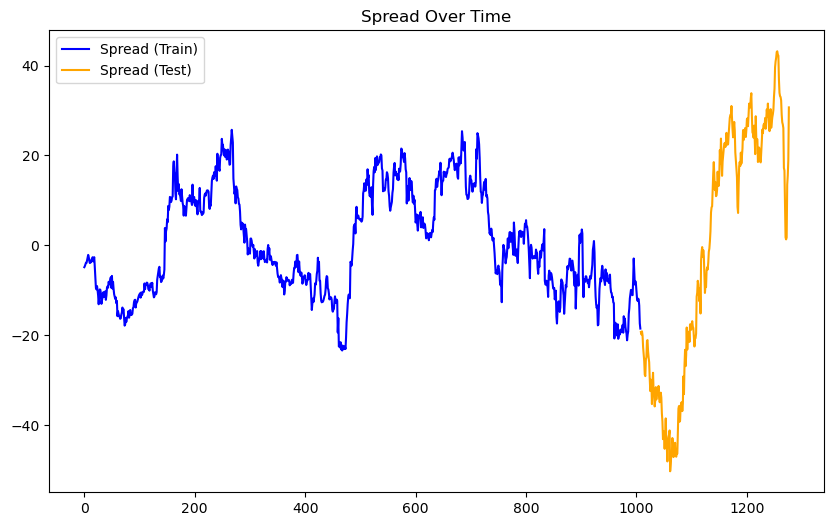

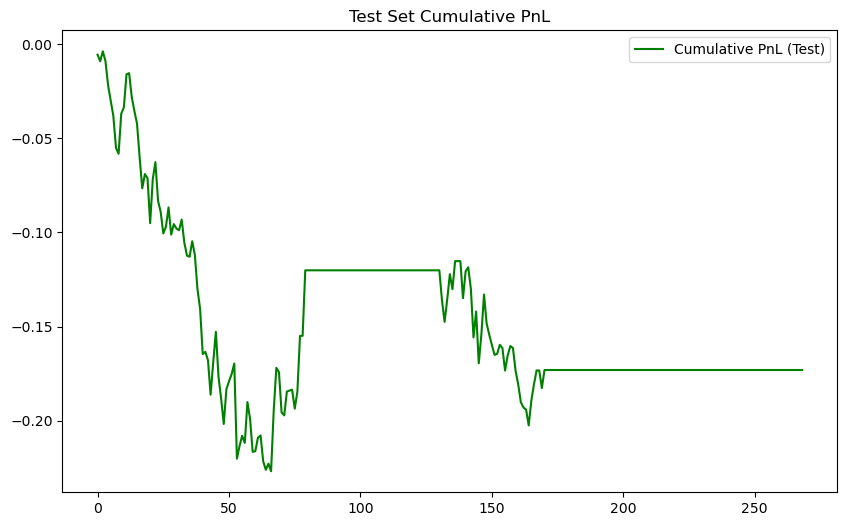

Best Test Sharpe Ratio: 1.91
Best Parameters: {'long_threshold': -2, 'short_threshold': 2, 'exit_threshold': 0.5, 'hedge_ratio_lookback': 100, 'lookback_window': 100}


In [65]:
param_grid = {
    "long_threshold": [-2, -1],
    "short_threshold": [1,2],
    "exit_threshold": [0.5, 1],
    "hedge_ratio_lookback": [100, 200, 252],
    "lookback_window": [100, 200, 252],
}

from itertools import product

best_sharpe = -np.inf
best_params = None

for params in product(*param_grid.values()):
    param_dict = dict(zip(param_grid.keys(), params))

    # Update parameters dynamically
    long_threshold = param_dict["long_threshold"]
    short_threshold = param_dict["short_threshold"]
    exit_threshold = param_dict["exit_threshold"]
    hedge_ratio_lookback = param_dict["hedge_ratio_lookback"]
    lookback_window = param_dict["lookback_window"]

    # Run the strategy with new parameters
    # (Assume we refactor the backtest function to accept these as inputs)
    sharpe_test = run_strategy(long_threshold, short_threshold, exit_threshold, hedge_ratio_lookback, lookback_window)

    # Track the best performing combination
    if sharpe_test > best_sharpe:
        best_sharpe = sharpe_test
        best_params = param_dict

print(f"Best Test Sharpe Ratio: {best_sharpe:.2f}")
print("Best Parameters:", best_params)